In [1]:
import pandas as pd
import numpy as np
from scipy.special import digamma
from scipy.optimize import root
from scipy.stats import gamma
import matplotlib.pyplot as plt
import polars as pl
from numba import njit
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, confusion_matrix
import xgboost as xgb
### transformer check

### First try

In [30]:
datasets["full_train"].columns

Index(['i', 'j', 'dt', 'dr', 'dr_cyl', 'dx', 'dy', 'dz', 'dphi', 'ds2',
       'beta_eff', 'time_residual', 'r1', 'r2', 'z1', 'z2', 'E1', 'E2',
       'E_sum', 'E_diff', 'E_ratio', 'label1', 'label2', 'target', 'is_edge'],
      dtype='object')

In [ ]:
ENERGY_FEATURES = ["E1","E2","E_sum", "E_diff", "E_ratio"]

[0]	validation_0-logloss:0.61382	validation_1-logloss:0.61367
[35]	validation_0-logloss:0.09871	validation_1-logloss:0.09886

FULL TEST
AUC  : 0.9954054526149273
AP   : 0.9959883302307075
ACC  : 0.9658246656760773

FIDUCIAL TEST
AUC  : 0.9985730593607306
AP   : 0.9999480622976036
ACC  : 0.9779735682819384

EDGE TEST
AUC  : 0.993531198436137
AP   : 0.9911188167776286
ACC  : 0.9623003194888179


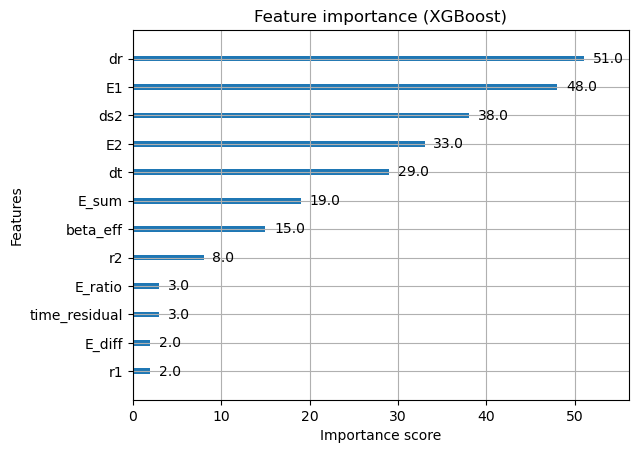

In [47]:
#GEOMETRY_FEATURES = ["r1", "r2", "z1", "z2", 'dr_cyl', 'dx', 'dy', 'dz', 'dphi']
GEOMETRY_FEATURES = [ 'dr_cyl', 'dx', 'dy', 'dz']

DROP_ALWAYS = ["i", "j", "target", "is_edge","label1","label2"]

def split_xy(df, drop_extra=None):
    drop_cols = DROP_ALWAYS.copy()

    if drop_extra is not None:
        drop_cols += drop_extra

    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["target"]
    return X, y
full_train = pl.read_parquet("full_train.parquet")
full_val = pl.read_parquet("full_val.parquet")
full_test = pl.read_parquet("full_test.parquet")

fid_train = pl.read_parquet("fid_train.parquet")
fid_val = pl.read_parquet("fid_val.parquet")
fid_test = pl.read_parquet("fid_test.parquet")

edge_train = pl.read_parquet("edge_train.parquet")
edge_val = pl.read_parquet("edge_val.parquet")
edge_test = pl.read_parquet("edge_test.parquet")

datasets = {
    "full_train": full_train,
    "full_val": full_val,
    "full_test": full_test,

    "fid_train": fid_train,
    "fid_val": fid_val,
    "fid_test": fid_test,

    "edge_train": edge_train,
    "edge_val": edge_val,
    "edge_test": edge_test,
}

for k in datasets:
    datasets[k] = datasets[k].to_pandas()


X_train, y_train = split_xy(datasets["full_train"],GEOMETRY_FEATURES)
X_val, y_val     = split_xy(datasets["full_val"],GEOMETRY_FEATURES)
X_test, y_test   = split_xy(datasets["full_test"],GEOMETRY_FEATURES)

"""
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    eval_metric="logloss"
)
"""
model = xgb.XGBClassifier(
    n_estimators=36,     
    max_depth=3,         
    learning_rate=0.1,   
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    eval_metric="logloss"
)
model.fit(X_train,y_train,eval_set=[(X_train, y_train), (X_val, y_val)],verbose=50)

def evaluate(name, df, drop_extra=None):
    X, y = split_xy(df, drop_extra=drop_extra)  
    
    prob = model.predict_proba(X)[:, 1]
    pred = (prob > 0.5).astype(int)
    auc = roc_auc_score(y, prob)
    ap  = average_precision_score(y, prob)
    acc = accuracy_score(y, pred)
    
    print(f"\n{name}")   
    print("AUC  :", auc)
    print("AP   :", ap)
    print("ACC  :", acc)

evaluate("FULL TEST", datasets["full_test"],  drop_extra=GEOMETRY_FEATURES)
evaluate("FIDUCIAL TEST", datasets["fid_test"],   drop_extra=GEOMETRY_FEATURES)
evaluate("EDGE TEST", datasets["edge_test"],  drop_extra=GEOMETRY_FEATURES)

import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=15)
plt.title("Feature importance (XGBoost)")
plt.show()

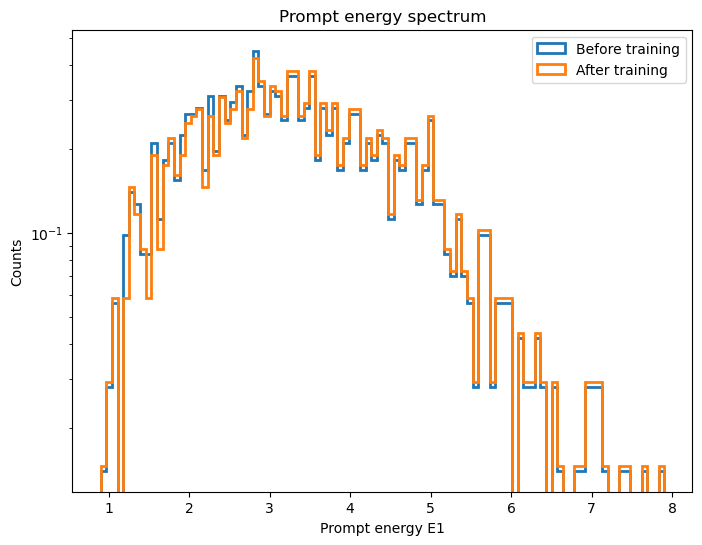

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# eventi veri prompt
true_prompt_before = datasets["full_test"].query("label1 == 1")["E1"]

X_test, y_test = split_xy(datasets["full_test"],drop_extra=GEOMETRY_FEATURES)

prob_test = model.predict_proba(X_test)[:,1]

# threshold classificazione
threshold = 0.397

selected_mask = prob_test > threshold

selected_df = datasets["full_test"][selected_mask]

# prompt ricostruiti
true_prompt_after = selected_df.query("label1 == 1")["E1"]
plt.figure(figsize=(8,6))

plt.hist(true_prompt_before, bins=100,density=True, histtype="step", linewidth=2, label="Before training")
plt.hist(true_prompt_after, bins=100,density=True, histtype="step", linewidth=2, label="After training")


plt.yscale("log")

plt.xlabel("Prompt energy E1")
plt.ylabel("Counts")
plt.title("Prompt energy spectrum")
plt.legend()

plt.show()



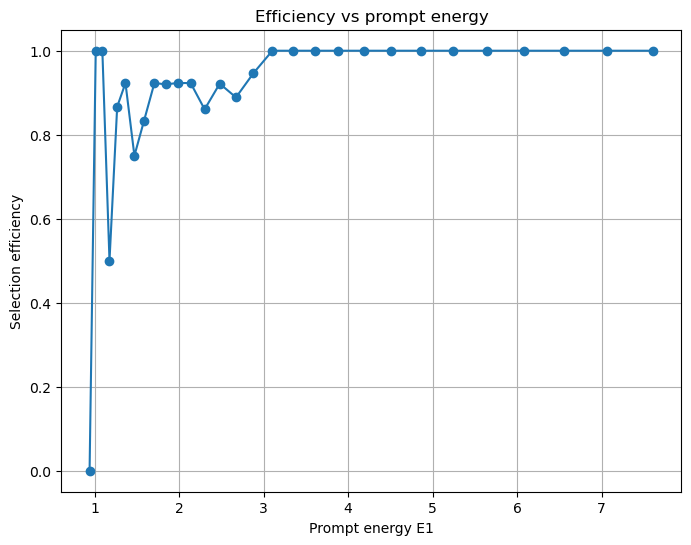

In [49]:
bins = np.logspace(np.log10(true_prompt_before.min() + 1e-6), np.log10(true_prompt_before.max()), 30)

h_before, _ = np.histogram(true_prompt_before, bins=bins)
h_after, _  = np.histogram(true_prompt_after, bins=bins)

efficiency = h_after / (h_before + 1e-12)

bin_centers = np.sqrt(bins[:-1] * bins[1:])

plt.figure(figsize=(8,6))

plt.plot(bin_centers, efficiency, marker="o")



plt.xlabel("Prompt energy E1")
plt.ylabel("Selection efficiency")
plt.title("Efficiency vs prompt energy")

plt.grid(True)

plt.show()

In [40]:
from sklearn.metrics import roc_auc_score

for feat in ["E1", "E2", "E_sum"]:

    auc = roc_auc_score(y_train, X_train[feat])

    print(feat, auc)

E1 0.8650420786885058
E2 0.5795685682950998
E_sum 0.8661958474132074


In [ ]:
### Test features importance 

TRAINING: FULL FEATURES
AUC : 0.9964294616273843
AP  : 0.9967242204978317
ACC : 0.9692917285785042
TRAINING: NO ENERGY
AUC : 0.9838562795745774
AP  : 0.9825435416734817
ACC : 0.9390787518573551
TRAINING: ONLY ENERGY
AUC : 0.9964294616273843
AP  : 0.9967242204978317
ACC : 0.9692917285785042


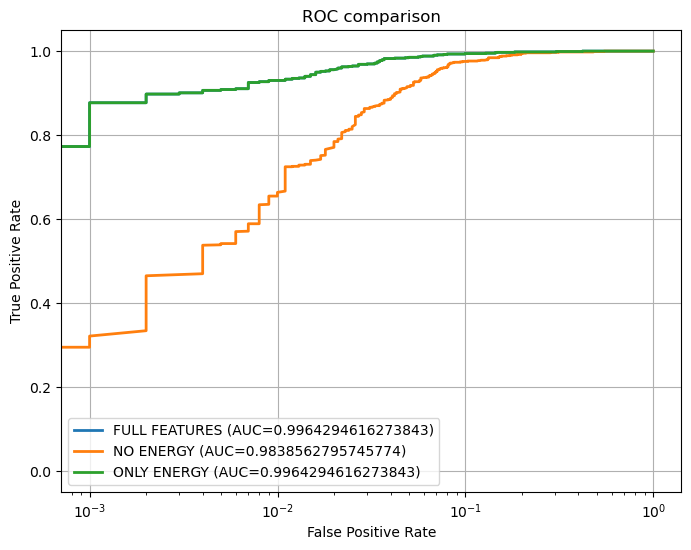

<Figure size 800x600 with 0 Axes>

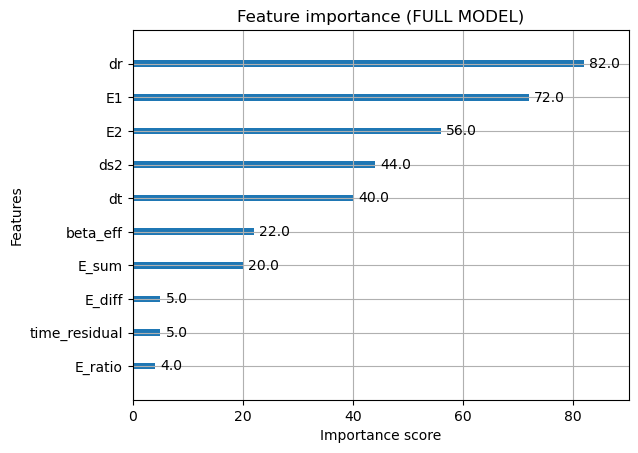

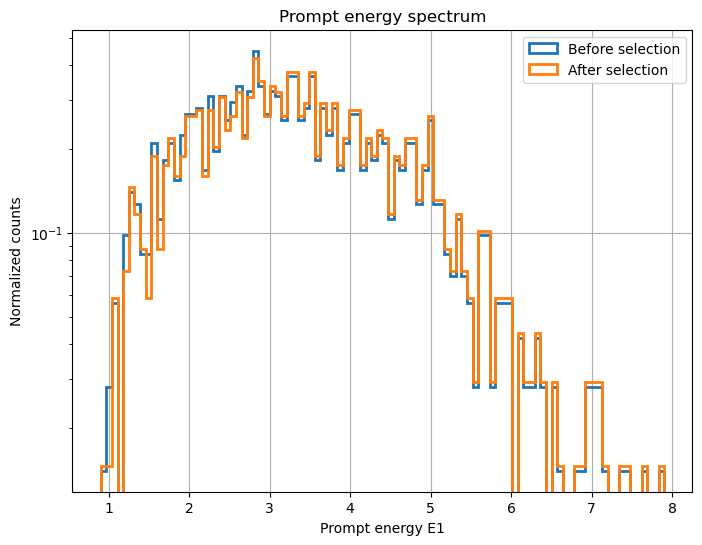

ENERGY FEATURE STANDALONE AUC
E1 -> AUC = 0.8650420786885058
E2 -> AUC = 0.5795685682950998
E_sum -> AUC = 0.8661958474132074
E_diff -> AUC = 0.6973343032424258
E_ratio -> AUC = 0.7414446972951924


In [83]:
from sklearn.metrics import roc_auc_score,average_precision_score,accuracy_score,roc_curve


ENERGY_FEATURES = ["E1","E2","E_sum", "E_diff", "E_ratio"]
GEOMETRY_FEATURES = ["r1", "r2", "z1", "z2", 'dr_cyl', 'dx', 'dy', 'dz', 'dphi']
#GEOMETRY_FEATURES = [ 'dr_cyl', 'dx', 'dy', 'dz']

DROP_ALWAYS = ["i", "j", "target", "is_edge","label1","label2"]


full_train = pl.read_parquet("full_train.parquet").to_pandas()
full_val   = pl.read_parquet("full_val.parquet").to_pandas()
full_test  = pl.read_parquet("full_test.parquet").to_pandas()

def split_xy(df, drop_extra=None):

    drop_cols = DROP_ALWAYS.copy()

    if drop_extra is not None:
        drop_cols += drop_extra

    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["target"]

    return X, y

def train_model(name, drop_extra):

    print(f"TRAINING: {name}")

    X_train, y_train = split_xy(full_train, drop_extra)
    X_val, y_val     = split_xy(full_val, drop_extra)
    X_test, y_test   = split_xy(full_test, drop_extra)

    model = xgb.XGBClassifier(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="logloss"
    )

    model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

    # predictions
    prob = model.predict_proba(X_test)[:,1]
    pred = (prob > 0.5).astype(int)

    auc = roc_auc_score(y_test, prob)
    ap  = average_precision_score(y_test, prob)
    acc = accuracy_score(y_test, pred)

    print(f"AUC : {auc}")
    print(f"AP  : {ap}")
    print(f"ACC : {acc}")

    return {
        "name": name,
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "prob": prob,
        "auc": auc
    }


full_result = train_model("FULL FEATURES",drop_extra=GEOMETRY_FEATURES)

no_energy_result = train_model("NO ENERGY",drop_extra=GEOMETRY_FEATURES + ENERGY_FEATURES)

only_energy_drop = GEOMETRY_FEATURES.copy()

only_energy_result = train_model("ONLY ENERGY",drop_extra=only_energy_drop)
"""
plt.figure(figsize=(8,6))

for result in [full_result,no_energy_result, only_energy_result]:

    fpr, tpr, _ = roc_curve(result["y_test"],result["prob"])

    plt.plot(fpr, tpr,linewidth=2, label=f'{result["name"]} (AUC={result["auc"]})')

plt.xscale("log")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC comparison")
plt.legend()
plt.grid(True)
plt.show()
"""
plt.figure(figsize=(8,6))

xgb.plot_importance(full_result["model"], max_num_features=15)

plt.title("Feature importance (FULL MODEL)")
plt.show()

threshold = 0.397
selected_mask = full_result["prob"] > threshold

selected_df = full_test[selected_mask]

# true prompt before
prompt_before = full_test.query("label1 == 1")["E1"]

# prompt after selection
prompt_after = selected_df.query("label1 == 1")["E1"]

plt.figure(figsize=(8,6))

plt.hist(prompt_before, bins=100,density=True, histtype="step", linewidth=2, label="Before selection")
plt.hist(prompt_after, bins=100,density=True, histtype="step", linewidth=2, label="After selection")
plt.yscale("log")
plt.xlabel("Prompt energy E1")
plt.ylabel("Normalized counts")
plt.title("Prompt energy spectrum")
plt.legend()
plt.grid(True)
plt.show()


bins = np.logspace(np.log10(prompt_before.min() + 1e-6),np.log10(prompt_before.max()),30)

h_before, _ = np.histogram(prompt_before,bins=bins)

h_after, _ = np.histogram(prompt_after,bins=bins)

efficiency = h_after / (h_before + 1e-12)

bin_centers = np.sqrt(bins[:-1] * bins[1:])
"""
plt.figure(figsize=(8,6))

plt.plot(bin_centers,efficiency,marker="o")

plt.xscale("log")

plt.xlabel("Prompt energy E1")
plt.ylabel("Selection efficiency")

plt.title("Efficiency vs prompt energy")

plt.grid(True)

plt.show()

"""
print("ENERGY FEATURE STANDALONE AUC")
X_train_full, y_train_full = split_xy(full_train,drop_extra=GEOMETRY_FEATURES)

for feat in ENERGY_FEATURES:

    auc = roc_auc_score(y_train_full,X_train_full[feat])

    print(f"{feat} -> AUC = {auc}")

In [44]:
full_test.columns

Index(['i', 'j', 'dt', 'dr', 'dr_cyl', 'dx', 'dy', 'dz', 'dphi', 'ds2',
       'beta_eff', 'time_residual', 'r1', 'r2', 'z1', 'z2', 'E1', 'E2',
       'E_sum', 'E_diff', 'E_ratio', 'label1', 'label2', 'target', 'is_edge'],
      dtype='object')

### Best parameters for the model

  0%|          | 0/40 [00:00<?, ?it/s]


── Best base params ──
  n_estimators: 222
  max_depth: 4
  learning_rate: 0.11369309874095086
  subsample: 0.643662885231576
  colsample_bytree: 0.944992359672228
  min_child_weight: 12
  reg_lambda: 3.7461715255494843
  reg_alpha: 1.69181538504838
  val_logloss: 0.05139


  0%|          | 0/40 [00:00<?, ?it/s]


── Best final params ──
  n_estimators: 639
  max_depth: 5
  learning_rate: 0.03826288253820326
  subsample: 0.8158402074910689
  colsample_bytree: 0.8639148454167632
  min_child_weight: 3
  reg_lambda: 2.7636904926151735
  reg_alpha: 0.5723724825085
  val_AUC: 0.99818
[0]	validation_0-logloss:0.81438	validation_1-logloss:0.82042
[50]	validation_0-logloss:0.15387	validation_1-logloss:0.15350
[100]	validation_0-logloss:0.08365	validation_1-logloss:0.08398
[150]	validation_0-logloss:0.06661	validation_1-logloss:0.06799
[200]	validation_0-logloss:0.05819	validation_1-logloss:0.06052
[250]	validation_0-logloss:0.05397	validation_1-logloss:0.05692
[300]	validation_0-logloss:0.05196	validation_1-logloss:0.05546
[350]	validation_0-logloss:0.05054	validation_1-logloss:0.05476
[400]	validation_0-logloss:0.04946	validation_1-logloss:0.05424
[450]	validation_0-logloss:0.04858	validation_1-logloss:0.05385
[500]	validation_0-logloss:0.04775	validation_1-logloss:0.05364
[550]	validation_0-logloss:0

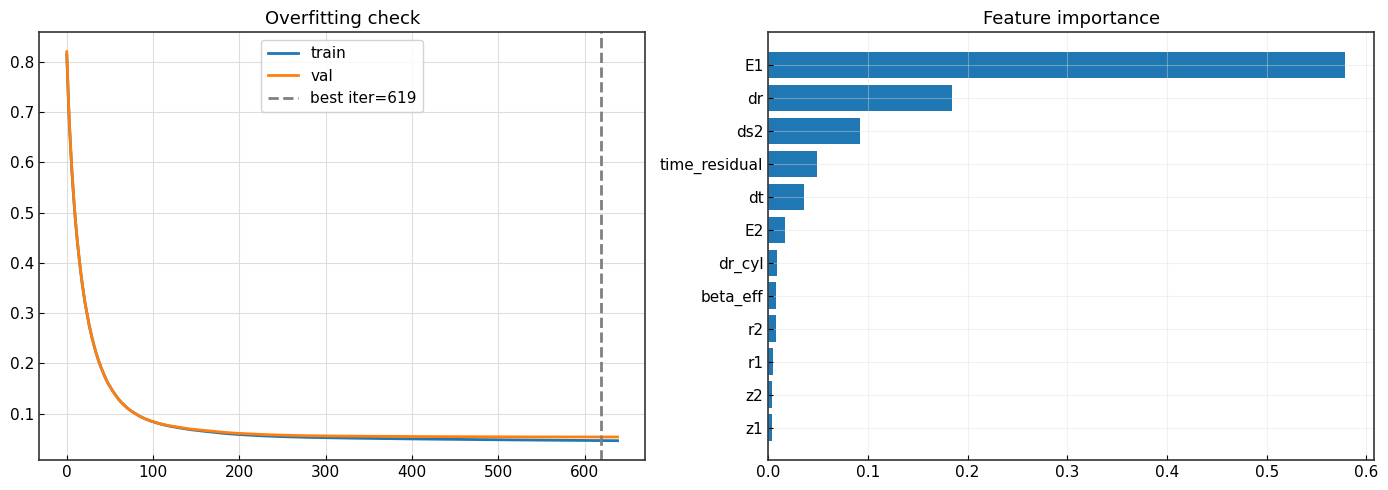

      feature  importance
           E1    0.578865
           dr    0.183970
          ds2    0.091877
time_residual    0.048942
           dt    0.035632
           E2    0.016552
       dr_cyl    0.008777
     beta_eff    0.007661
           r2    0.007354
           r1    0.004579
           z2    0.003878
           z1    0.003700
         dphi    0.002468
           dy    0.002184
           dx    0.001874

── Optuna base study — top 5 trials ──
 number    value  params_colsample_bytree  params_learning_rate  params_max_depth  params_min_child_weight  params_n_estimators  params_reg_alpha  params_reg_lambda  params_subsample
     23 0.051387                 0.944992              0.113693                 4                       12                  222          1.691815           3.746172          0.643663
     31 0.051534                 0.947088              0.096326                 4                       17                  237          1.638958           4.606910          0.64

In [6]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_train, y_train = split_xy(train, drop_extra=ENERGY_FEATURES)
X_val,   y_val   = split_xy(val,   drop_extra=ENERGY_FEATURES)
X_test,  y_test  = split_xy(test,  drop_extra=ENERGY_FEATURES)
E_train = train["E1"].values

ADV_COEFF = 8
ADV_COEFF_LOW = 3.0
ENERGY_THRESHOLD = 3.0
N_EPOCHS  = 8    # meno epoch durante search per velocità

bins_adv = np.concatenate([
    np.linspace(E_train.min(), ENERGY_THRESHOLD, 25),
    np.linspace(ENERGY_THRESHOLD, E_train.max(), 10)
])

def run_adversarial_loop(base_params, n_epochs=N_EPOCHS):
    w  = np.ones(len(train))
    best_val_loss = np.inf
    best_w = w.copy()

    for epoch in range(n_epochs):
        model_adv = xgb.XGBClassifier(**base_params)
        model_adv.fit(
            X_train, y_train,
            sample_weight = w,
            eval_set      = [(X_val, y_val)],
            verbose       = False
        )
        val_loss    = min(model_adv.evals_result()["validation_0"]["logloss"])
        p_train     = model_adv.predict_proba(X_train)[:, 1]
        bin_id      = np.digitize(E_train, bins_adv)
        corr_penalty = np.zeros(len(p_train))

        for b in np.unique(bin_id):
            mask = bin_id == b
            if mask.sum() < 15:
                continue
            mean_score = p_train[mask].mean()
            penalty    = p_train[mask] - mean_score
            ew         = ADV_COEFF_LOW if bins_adv[min(b, len(bins_adv)-1)] < ENERGY_THRESHOLD else 1.0
            corr_penalty[mask] = penalty * ew

        w = np.exp(-ADV_COEFF * np.abs(corr_penalty))
        w = np.clip(w, 0.05, 1.0)
        w /= w.mean()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_w        = w.copy()

    return best_w, best_val_loss


def objective_base(trial):
    base_params = dict(
        n_estimators          = trial.suggest_int("n_estimators", 80, 250),
        max_depth             = trial.suggest_int("max_depth", 3, 6),
        learning_rate         = trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        subsample             = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree      = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight      = trial.suggest_int("min_child_weight", 3, 20),
        reg_lambda            = trial.suggest_float("reg_lambda", 0.5, 5.0),
        reg_alpha             = trial.suggest_float("reg_alpha", 0.0, 2.0),
        tree_method           = "hist",
        eval_metric           = "logloss",
        early_stopping_rounds = 15,
        random_state          = 42
    )
    _, val_loss = run_adversarial_loop(base_params)
    return val_loss

study_base = optuna.create_study(
    direction = "minimize",
    sampler   = TPESampler(seed=42)
)
study_base.optimize(objective_base, n_trials=40, show_progress_bar=True)

best_base_params = study_base.best_params
best_base_params.update({
    "tree_method": "hist",
    "eval_metric": "logloss",
    "early_stopping_rounds": 15,
    "random_state": 42
})

print("\n── Best base params ──")
for k, v in study_base.best_params.items():
    print(f"  {k}: {v}")
print(f"  val_logloss: {study_base.best_value:.5f}")

# calcola i pesi con i best base params (loop completo)
best_w, _ = run_adversarial_loop(best_base_params, n_epochs=N_EPOCHS)

def objective_final(trial):
    final_params = dict(
        n_estimators          = trial.suggest_int("n_estimators", 200, 800),
        max_depth             = trial.suggest_int("max_depth", 3, 6),
        learning_rate         = trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        subsample             = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree      = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight      = trial.suggest_int("min_child_weight", 3, 20),
        reg_lambda            = trial.suggest_float("reg_lambda", 0.5, 5.0),
        reg_alpha             = trial.suggest_float("reg_alpha", 0.0, 2.0),
        tree_method           = "hist",
        eval_metric           = "logloss",
        early_stopping_rounds = 25,
        random_state          = 42
    )
    m = xgb.XGBClassifier(**final_params)
    m.fit(
        X_train, y_train,
        sample_weight = best_w,
        eval_set      = [(X_val, y_val)],
        verbose       = False
    )
    # ottimizza AUC sul val set, non solo logloss
    p_val = m.predict_proba(X_val)[:, 1]
    auc   = roc_auc_score(y_val, p_val)
    return -auc   # minimizza → massimizza AUC

study_final = optuna.create_study(
    direction = "minimize",
    sampler   = TPESampler(seed=42)
)
study_final.optimize(objective_final, n_trials=40, show_progress_bar=True)

best_final_params = study_final.best_params
best_final_params.update({
    "tree_method": "hist",
    "eval_metric": "logloss",
    "early_stopping_rounds": 25,
    "random_state": 42
})

print("\n── Best final params ──")
for k, v in study_final.best_params.items():
    print(f"  {k}: {v}")
print(f"  val_AUC: {-study_final.best_value:.5f}")

best_w_final, _ = run_adversarial_loop(best_base_params, n_epochs=15)  # loop completo

final_model = xgb.XGBClassifier(**best_final_params)
final_model.fit(
    X_train, y_train,
    sample_weight = best_w_final,
    eval_set      = [(X_train, y_train), (X_val, y_val)],
    verbose       = 50
)

prob = final_model.predict_proba(X_test)[:, 1]
auc  = roc_auc_score(y_test, prob)
ap   = average_precision_score(y_test, prob)
print(f"\nTest — AUC: {auc:.4f}  AP: {ap:.4f}")

results = final_model.evals_result()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results["validation_0"]["logloss"], label="train")
axes[0].plot(results["validation_1"]["logloss"], label="val")
axes[0].axvline(final_model.best_iteration, color="gray", linestyle="--",
                label=f"best iter={final_model.best_iteration}")
axes[0].set_title("Overfitting check"); axes[0].legend(); axes[0].grid(True)

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

axes[1].barh(feat_imp["feature"].head(12), feat_imp["importance"].head(12))
axes[1].invert_yaxis()
axes[1].set_title("Feature importance"); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()
print(feat_imp.head(15).to_string(index=False))

print("\n── Optuna base study — top 5 trials ──")
df_base = study_base.trials_dataframe().sort_values("value").head(5)
print(df_base[["number","value"] + [c for c in df_base.columns if c.startswith("params_")]].to_string(index=False))

print("\n── Optuna final study — top 5 trials ──")
df_final = study_final.trials_dataframe().sort_values("value").head(5)
print(df_final[["number","value"] + [c for c in df_final.columns if c.startswith("params_")]].to_string(index=False))

In [309]:
X_train.columns


Index(['dt', 'dr', 'dr_cyl', 'dx', 'dy', 'dz', 'dphi', 'ds2', 'beta_eff',
       'time_residual', 'r1', 'r2', 'z1', 'z2', 'E2'],
      dtype='object')

### ADVERSARIAL ENERGY DE-CORRELATION TRAINING


In [ ]:
train = pl.read_parquet("full_train.parquet").to_pandas()
val   = pl.read_parquet("full_val.parquet").to_pandas()
test  = pl.read_parquet("full_test.parquet").to_pandas()

ENERGY_FEATURES = ["E_sum", "E_diff", "E_ratio"]
DROP_ALWAYS     = ["i", "j", "target", "is_edge", "label1", "label2"]

def split_xy(df, drop_extra=None):
    drop_cols = DROP_ALWAYS.copy()
    if drop_extra is not None:
        drop_cols += drop_extra
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["target"]
    return X, y

X_train, y_train = split_xy(train, drop_extra=ENERGY_FEATURES)
X_val,   y_val   = split_xy(val,   drop_extra=ENERGY_FEATURES)
X_test,  y_test  = split_xy(test,  drop_extra=ENERGY_FEATURES)

E_train = train["E1"].values
E_val   = val["E1"].values

N_EPOCHS        = 15
ADV_COEFF       = 5       # penalità avversariale — non esagerare
ADV_COEFF_LOW   = 3.0     # moltiplicatore extra per E1 < 3
ENERGY_THRESHOLD= 3.0
N_BINS_LOW      = 25      # bins fini nella regione problematica
N_BINS_HIGH     = 10

BASE_PARAMS = dict(
    n_estimators   = 222,
    max_depth      = 4,
    learning_rate  = 0.11369309874095086,
    subsample      = 0.64,
    colsample_bytree = 0.945,
    min_child_weight = 12,   # contrasta overfitting
    reg_lambda     = 3.75,   # L2
    reg_alpha      = 1.69,   # L1
    tree_method    = "hist",
    eval_metric    = "logloss",
    early_stopping_rounds = 15,
    random_state   = 42
)

bins_adv = np.concatenate([np.linspace(E_train.min(), ENERGY_THRESHOLD, N_BINS_LOW),np.linspace(ENERGY_THRESHOLD, E_train.max(), N_BINS_HIGH)])

w = np.ones(len(train))
best_val_loss = np.inf
best_w        = w.copy()

for epoch in range(N_EPOCHS):

    model_adv = xgb.XGBClassifier(**BASE_PARAMS)
    model_adv.fit(
        X_train, y_train,
        sample_weight = w,
        eval_set = [(X_val, y_val)],
        verbose = False
    )

    val_loss = model_adv.evals_result()["validation_0"]["logloss"]
    best_round_loss = min(val_loss)

    p_train = model_adv.predict_proba(X_train)[:, 1]
    p_val = model_adv.predict_proba(X_val)[:, 1]

    bin_id  = np.digitize(E_train, bins_adv)
    corr_penalty = np.zeros(len(p_train))

    for b in np.unique(bin_id):
        mask = bin_id == b
        if mask.sum() < 15:
            continue
        mean_score = p_train[mask].mean()
        penalty    = p_train[mask] - mean_score
        ew         = ADV_COEFF_LOW if bins_adv[min(b, len(bins_adv)-1)] < ENERGY_THRESHOLD else 1.0
        corr_penalty[mask] = penalty * ew

    w = np.exp(-ADV_COEFF * np.abs(corr_penalty))
    w = np.clip(w, 0.05, 1.0)   # evita pesi zero che azzerano campioni
    w /= w.mean()                # rinormalizza per stabilità numerica

    auc_val = roc_auc_score(y_val, p_val)
    print(f"Epoch {epoch:02d} | val_logloss={best_round_loss:.4f} | val_AUC={auc_val:.4f} "
          f"| w_range=[{w.min():.3f}, {w.max():.3f}]")

    if best_round_loss < best_val_loss:
        best_val_loss = best_round_loss
        best_w        = w.copy()

print(f"\nMiglior val_logloss: {best_val_loss:.4f} — uso i pesi di quell'epoch per il final model")

FINAL_PARAMS = dict(
    n_estimators     = 639,
    max_depth        = 5,
    learning_rate    = 0.03,
    subsample        = 0.94,
    colsample_bytree = 0.86,
    min_child_weight = 13,
    reg_lambda       = 2.99,
    reg_alpha        = 0.51,
    tree_method      = "hist",
    eval_metric      = "logloss",
    early_stopping_rounds = 25,
    random_state     = 42
)

final_model = xgb.XGBClassifier(**FINAL_PARAMS)
#final_model.fit(X_train,y_train,eval_set=[(X_train, y_train), (X_val, y_val)],verbose=50)

final_model.fit(X_train, y_train, sample_weight = best_w, eval_set=[(X_train, y_train), (X_val, y_val)],verbose= 50)

prob = final_model.predict_proba(X_test)[:, 1]
auc  = roc_auc_score(y_test, prob)
ap   = average_precision_score(y_test, prob)
print(f"\nFinal model — AUC: {auc:.4f}  AP: {ap:.4f}")

results = final_model.evals_result()
plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["logloss"], label="train", alpha=0.8)
plt.plot(results["validation_1"]["logloss"], label="val",   alpha=0.8)
plt.axvline(final_model.best_iteration, color="gray", linestyle="--",
            label=f"best iter={final_model.best_iteration}")
plt.xlabel("Boosting round"); plt.ylabel("Logloss")
plt.title("Overfitting check"); plt.legend(); plt.grid(True); plt.show()

feat_imp = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)
print(feat_imp.head(15).to_string(index=False))

thresholds_scan = np.linspace(0, 1, 200)
f1_list = []
for thr in thresholds_scan:
    yp = (prob > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0,1]).ravel()
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1_list.append(2*prec*rec/(prec+rec) if (prec+rec)>0 else 0)

best_thr = thresholds_scan[np.argmax(f1_list)]
print(f"Best threshold (F1): {best_thr:.3f}")

y_pred = (prob > best_thr).astype(int)

bins_E = np.linspace(test["E1"].min(), test["E1"].max(), 80)
prompt_before = test.query("label1 == 1")["E1"]
prompt_after  = test.loc[(y_pred == 1) & (test["label1"] == 1), "E1"]

plt.figure(figsize=(8, 6))
plt.hist(prompt_before, bins=bins_E, histtype="step", lw=2, density=False, label="Before selection")
plt.hist(prompt_after,  bins=bins_E, histtype="step", lw=2, density=False, label="After selection")
plt.yscale("log")
plt.xlabel("Prompt energy E1"); plt.ylabel("Counts")
plt.title(f"Prompt energy spectrum (thr={best_thr:.3f})")
plt.legend(); plt.grid(True); plt.show()

Epoch 00 | val_logloss=0.0522 | val_AUC=0.9982 | w_range=[0.125, 2.502]
Epoch 01 | val_logloss=0.0555 | val_AUC=0.9980 | w_range=[0.124, 2.472]
Epoch 02 | val_logloss=0.0546 | val_AUC=0.9981 | w_range=[0.124, 2.477]
Epoch 03 | val_logloss=0.0555 | val_AUC=0.9980 | w_range=[0.124, 2.474]
Epoch 04 | val_logloss=0.0538 | val_AUC=0.9981 | w_range=[0.124, 2.478]
Epoch 05 | val_logloss=0.0564 | val_AUC=0.9980 | w_range=[0.123, 2.467]
Epoch 06 | val_logloss=0.0541 | val_AUC=0.9981 | w_range=[0.124, 2.484]
Epoch 07 | val_logloss=0.0548 | val_AUC=0.9981 | w_range=[0.124, 2.473]
Epoch 08 | val_logloss=0.0540 | val_AUC=0.9981 | w_range=[0.124, 2.476]
Epoch 09 | val_logloss=0.0552 | val_AUC=0.9981 | w_range=[0.124, 2.478]
Epoch 10 | val_logloss=0.0542 | val_AUC=0.9981 | w_range=[0.124, 2.474]
Epoch 11 | val_logloss=0.0547 | val_AUC=0.9981 | w_range=[0.124, 2.477]
Epoch 12 | val_logloss=0.0550 | val_AUC=0.9981 | w_range=[0.124, 2.471]
Epoch 13 | val_logloss=0.0546 | val_AUC=0.9981 | w_range=[0.124,

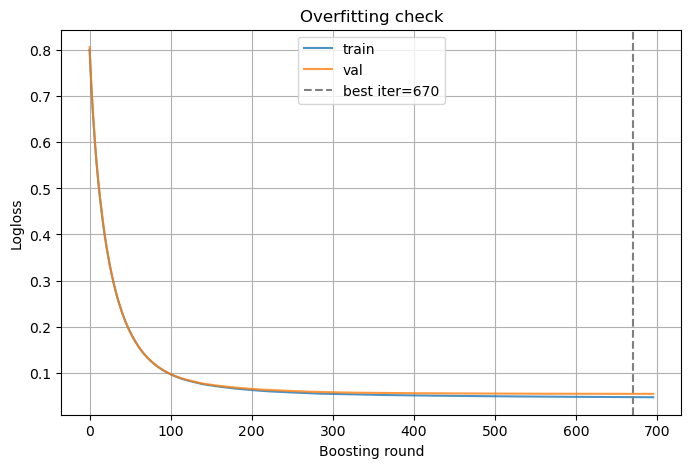

      feature  importance
           E1    0.632691
           dr    0.163643
          ds2    0.082398
           dt    0.036971
time_residual    0.019995
           E2    0.016427
       dr_cyl    0.010958
     beta_eff    0.007261
           r2    0.006929
           z2    0.004513
           z1    0.004269
           r1    0.004040
         dphi    0.003583
           dx    0.002522
           dy    0.002048
Best threshold (F1): 0.442


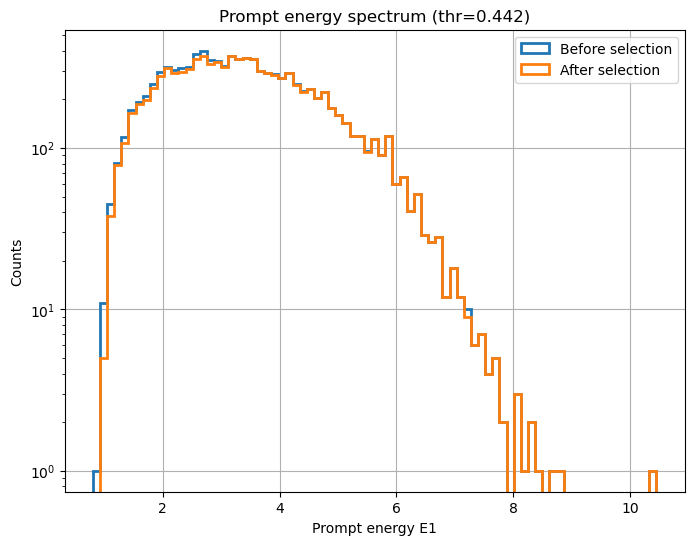

In [4]:
train = pl.read_parquet("full_train.parquet").to_pandas()
val   = pl.read_parquet("full_val.parquet").to_pandas()
test  = pl.read_parquet("full_test.parquet").to_pandas()

ENERGY_FEATURES = ["E_sum", "E_diff", "E_ratio"]
DROP_ALWAYS     = ["i", "j", "target", "is_edge", "label1", "label2"]

def split_xy(df, drop_extra=None):
    drop_cols = DROP_ALWAYS.copy()
    if drop_extra is not None:
        drop_cols += drop_extra
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["target"]
    return X, y

X_train, y_train = split_xy(train, drop_extra=ENERGY_FEATURES)
X_val,   y_val   = split_xy(val,   drop_extra=ENERGY_FEATURES)
X_test,  y_test  = split_xy(test,  drop_extra=ENERGY_FEATURES)

E_train = train["E1"].values
E_val   = val["E1"].values

N_EPOCHS        = 15
ADV_COEFF       = 5       # penalità avversariale — non esagerare
ADV_COEFF_LOW   = 3.0     # moltiplicatore extra per E1 < 3
ENERGY_THRESHOLD= 3.0
N_BINS_LOW      = 25      # bins fini nella regione problematica
N_BINS_HIGH     = 10

BASE_PARAMS = dict(
    n_estimators   = 222,
    max_depth      = 4,
    learning_rate  = 0.11369309874095086,
    subsample      = 0.64,
    colsample_bytree = 0.945,
    min_child_weight = 12,   # contrasta overfitting
    reg_lambda     = 3.75,   # L2
    reg_alpha      = 1.69,   # L1
    tree_method    = "hist",
    eval_metric    = "logloss",
    early_stopping_rounds = 15,
    random_state   = 42
)

bins_adv = np.concatenate([np.linspace(E_train.min(), ENERGY_THRESHOLD, N_BINS_LOW),np.linspace(ENERGY_THRESHOLD, E_train.max(), N_BINS_HIGH)])

w = np.ones(len(train))
best_val_loss = np.inf
best_w        = w.copy()

for epoch in range(N_EPOCHS):

    model_adv = xgb.XGBClassifier(**BASE_PARAMS)
    model_adv.fit(
        X_train, y_train,
        sample_weight = w,
        eval_set = [(X_val, y_val)],
        verbose = False
    )

    val_loss = model_adv.evals_result()["validation_0"]["logloss"]
    best_round_loss = min(val_loss)

    p_train = model_adv.predict_proba(X_train)[:, 1]
    p_val = model_adv.predict_proba(X_val)[:, 1]

    bin_id  = np.digitize(E_train, bins_adv)
    corr_penalty = np.zeros(len(p_train))

    for b in np.unique(bin_id):
        mask = bin_id == b
        if mask.sum() < 15:
            continue
        mean_score = p_train[mask].mean()
        penalty    = p_train[mask] - mean_score
        ew         = ADV_COEFF_LOW if bins_adv[min(b, len(bins_adv)-1)] < ENERGY_THRESHOLD else 1.0
        corr_penalty[mask] = penalty * ew

    w = np.exp(-ADV_COEFF * np.abs(corr_penalty))
    w = np.clip(w, 0.05, 1.0)   # evita pesi zero che azzerano campioni
    w /= w.mean()                # rinormalizza per stabilità numerica

    auc_val = roc_auc_score(y_val, p_val)
    print(f"Epoch {epoch:02d} | val_logloss={best_round_loss:.4f} | val_AUC={auc_val:.4f} "
          f"| w_range=[{w.min():.3f}, {w.max():.3f}]")

    if best_round_loss < best_val_loss:
        best_val_loss = best_round_loss
        best_w        = w.copy()

print(f"\nMiglior val_logloss: {best_val_loss:.4f} — uso i pesi di quell'epoch per il final model")

FINAL_PARAMS = dict(
    n_estimators     = 727,
    max_depth        = 6,
    learning_rate    = 0.03,
    subsample        = 0.94,
    colsample_bytree = 0.86,
    min_child_weight = 13,
    reg_lambda       = 2.99,
    reg_alpha        = 0.51,
    tree_method      = "hist",
    eval_metric      = "logloss",
    early_stopping_rounds = 25,
    random_state     = 42
)

final_model = xgb.XGBClassifier(**FINAL_PARAMS)
#final_model.fit(X_train,y_train,eval_set=[(X_train, y_train), (X_val, y_val)],verbose=50)

final_model.fit(X_train, y_train, sample_weight = best_w, eval_set=[(X_train, y_train), (X_val, y_val)],verbose= 50)

prob = final_model.predict_proba(X_test)[:, 1]
auc  = roc_auc_score(y_test, prob)
ap   = average_precision_score(y_test, prob)
print(f"\nFinal model — AUC: {auc:.4f}  AP: {ap:.4f}")

results = final_model.evals_result()
plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["logloss"], label="train", alpha=0.8)
plt.plot(results["validation_1"]["logloss"], label="val",   alpha=0.8)
plt.axvline(final_model.best_iteration, color="gray", linestyle="--",
            label=f"best iter={final_model.best_iteration}")
plt.xlabel("Boosting round"); plt.ylabel("Logloss")
plt.title("Overfitting check"); plt.legend(); plt.grid(True); plt.show()

feat_imp = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)
print(feat_imp.head(15).to_string(index=False))

thresholds_scan = np.linspace(0, 1, 200)
f1_list = []
for thr in thresholds_scan:
    yp = (prob > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0,1]).ravel()
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1_list.append(2*prec*rec/(prec+rec) if (prec+rec)>0 else 0)

best_thr = thresholds_scan[np.argmax(f1_list)]
print(f"Best threshold (F1): {best_thr:.3f}")

y_pred = (prob > best_thr).astype(int)

bins_E = np.linspace(test["E1"].min(), test["E1"].max(), 80)
prompt_before = test.query("label1 == 1")["E1"]
prompt_after  = test.loc[(y_pred == 1) & (test["label1"] == 1), "E1"]

plt.figure(figsize=(8, 6))
plt.hist(prompt_before, bins=bins_E, histtype="step", lw=2, density=False, label="Before selection")
plt.hist(prompt_after,  bins=bins_E, histtype="step", lw=2, density=False, label="After selection")
plt.yscale("log")
plt.xlabel("Prompt energy E1"); plt.ylabel("Counts")
plt.title(f"Prompt energy spectrum (thr={best_thr:.3f})")
plt.legend(); plt.grid(True); plt.show()

f1 eff purity threshold decision

In [3]:
threshold = best_thr

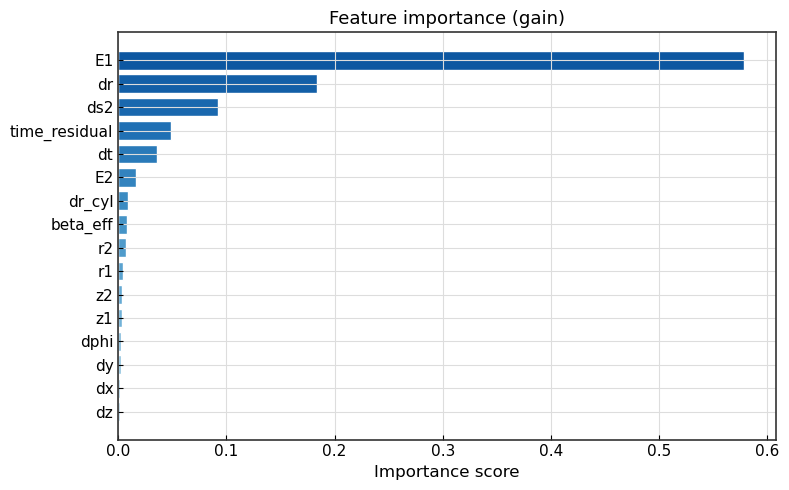

In [7]:
from visualization import plot_feature_importance
from pathlib import Path

plot_feature_importance(
    final_model.feature_importances_,
    X_train.columns,
    top_n=len(X_train.columns),
    title="Feature importance (gain)",
)
plt.savefig(Path("drive-download-20260624T132430Z-3-001/figs") / "feature_imp_adv.png", dpi=300, bbox_inches="tight")

plt.show()

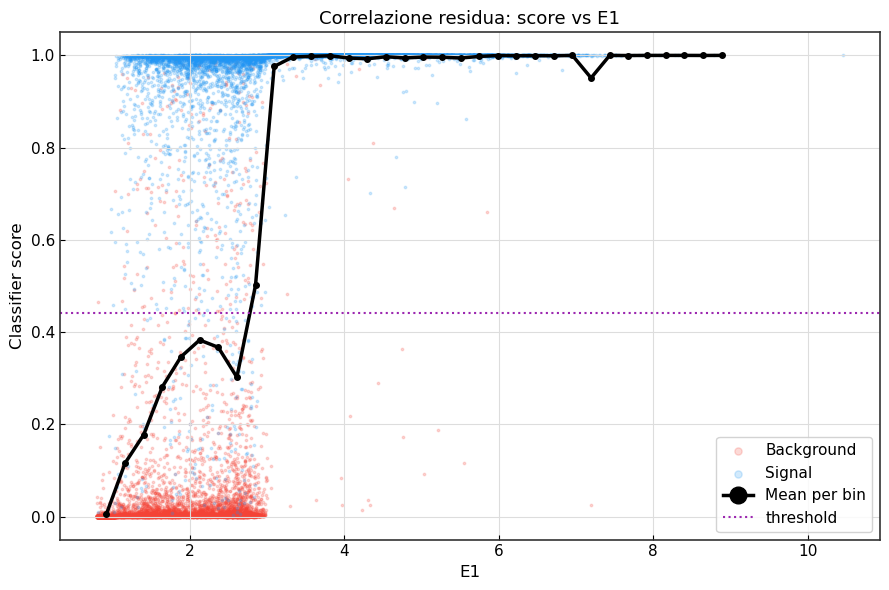

In [8]:
from visualization import plot_score_vs_variable
from pathlib import Path

plot_score_vs_variable(
    variable=test["E1"].values,
    scores=prob,
    y_true=y_test.values,
    threshold=best_thr,
    var_label="E1",
    title="Correlazione residua: score vs E1",
)
plt.savefig(Path("drive-download-20260624T132430Z-3-001/figs") / "score_ep_adv.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.calibration import calibration_curve

fraction_pos, mean_pred = calibration_curve(y_test, prob, n_bins=15)

plt.figure(figsize=(6, 5))
plt.plot(mean_pred, fraction_pos, marker="o", label="Modello")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfetta calibrazione")
plt.xlabel("Probabilità predetta")
plt.ylabel("Frazione positivi reali")
plt.title("Calibration curve")
plt.legend() 
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))

plt.scatter(test['E1'], prob, s=2, alpha=0.3)
plt.axhline(y=threshold, color='red', linestyle=':')
plt.xlabel("E1")
plt.ylabel("Classifier score")

plt.title("Energy vs score (after adversarial training)")
plt.savefig(Path("drive-download-20260624T132430Z-3-001/figs") / "en_score_adv.png", dpi=300, bbox_inches="tight")

plt.show()

### Subtraction of background with shifted datas

Normalization factor: 0.4999746249048434
shift_id=4: 862 coppie classificate come segnale
shift_id=6: 880 coppie classificate come segnale
shift_id=8: 893 coppie classificate come segnale
shift_id=10: 910 coppie classificate come segnale
shift_id=12: 934 coppie classificate come segnale
shift_id=14: 950 coppie classificate come segnale
shift_id=16: 936 coppie classificate come segnale
shift_id=18: 919 coppie classificate come segnale
shift_id=20: 935 coppie classificate come segnale


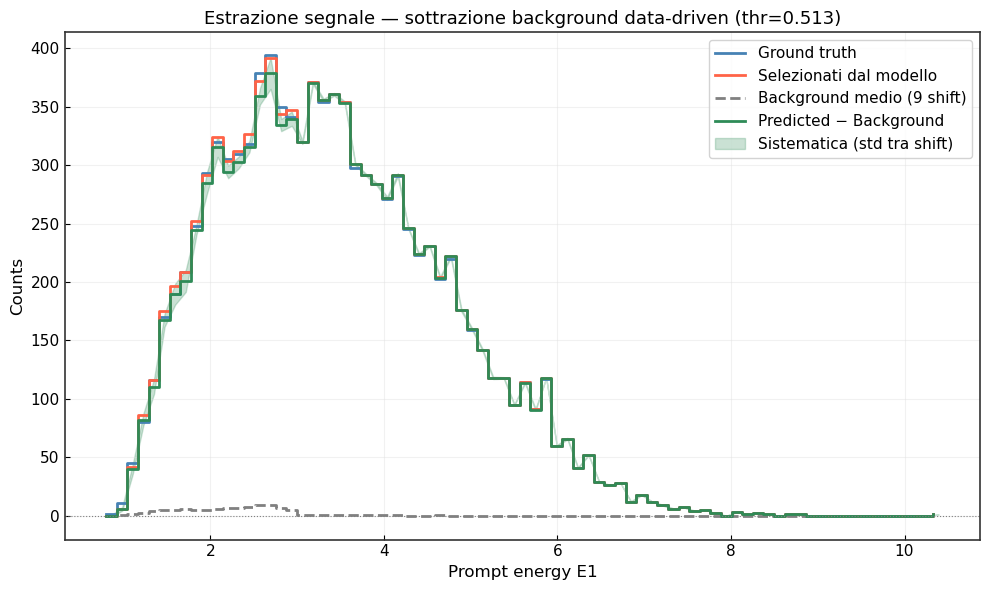

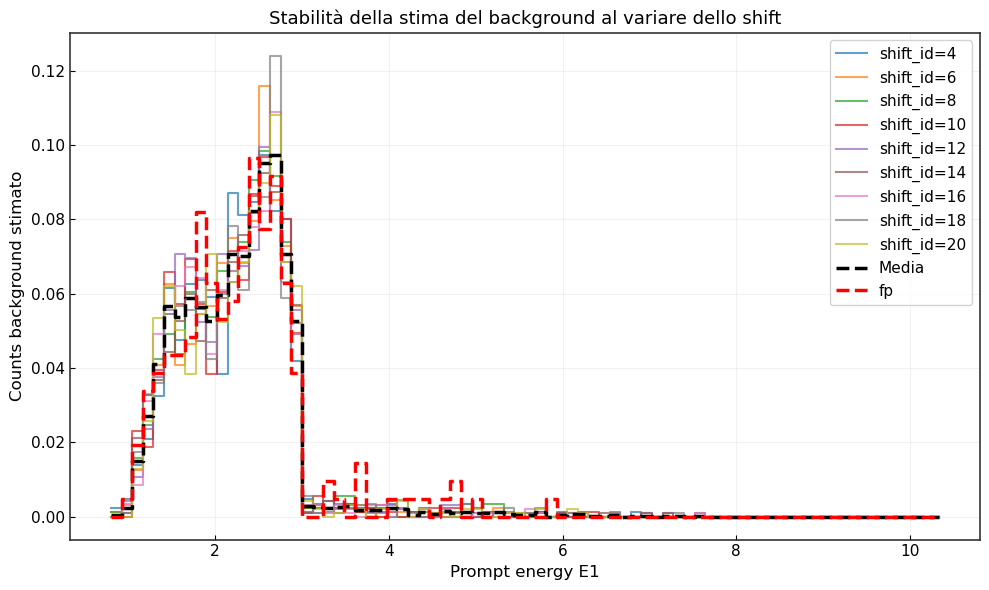

In [9]:
def split_shift(df, drop_extra=None):

    drop_cols = DROP_ALWAYS.copy()

    if drop_extra is not None:
        drop_cols += drop_extra
    drop_cols.append('shift_id')
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["target"]

    return X, y
prova = pl.read_parquet("full_test2.parquet").to_pandas()
#prova = prova.sample(n=20167, random_state=42).reset_index(drop=True)
T_test  = test["dt"].max()  - test["dt"].min()
T_prova = prova["dt"].max() - prova["dt"].min()

alpha = T_test / T_prova

print("Normalization factor:", alpha)


X_prova, y_prova = split_shift(prova, drop_extra=ENERGY_FEATURES)
prob2    = final_model.predict_proba(X_prova)[:, 1]
prova["score"] = prob2

bins = np.linspace(min(test["E1"].min(), prova["E1"].min()), max(test["E1"].max(), prova["E1"].max()), 80)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# istogramma per ogni shift_id separatamente
shift_ids = sorted(prova["shift_id"].unique())
shift_ids.remove(2)
spectra_bkg = []
for sid in shift_ids:
    mask = (prova["shift_id"] == sid) & (prova["score"] > threshold)
    h, _   = np.histogram(prova.loc[mask, "E1"], bins=bins)
    spectra_bkg.append(h)
    print(f"shift_id={sid}: {mask.sum():,} coppie classificate come segnale")

spectra_bkg  = np.array(spectra_bkg)          # shape: (N_shifts, N_bins)
h_bkg_mean   = spectra_bkg.mean(axis=0)
h_bkg_std    = spectra_bkg.std(axis=0)        # sistematica bin per bin

# spettro test originale
true_mask = y_test == 1
pred_mask = y_pred == 1
ht, _ = np.histogram(test.loc[true_mask, "E1"],  bins=bins)
hp, _ = np.histogram(test.loc[pred_mask, "E1"],  bins=bins)

fp_mask = (y_pred == 1) & (y_test== 0)
hfp, _ = np.histogram(test.loc[fp_mask, "E1"],  bins=bins)
ratio = len(test)/len(prova)
signal_sub = hp - h_bkg_mean*0.15
hfp_norm = hfp / (hfp.sum() + 1e-12)

plt.figure(figsize=(10, 6))
plt.step(bins[:-1], ht, where="post", lw=2, color="steelblue", label="Ground truth")
plt.step(bins[:-1], hp, where="post", lw=2, color="tomato",    label="Selezionati dal modello")
plt.step(bins[:-1], h_bkg_mean*ratio, where="post", lw=2, color="gray",      linestyle="--", label=f"Background medio ({len(shift_ids)} shift)")
plt.step(bins[:-1], signal_sub, where="post", lw=2, color="seagreen",  label="Predicted − Background")
plt.fill_between(bin_centers,signal_sub - h_bkg_std, signal_sub + h_bkg_std, alpha=0.25, color="seagreen", label="Sistematica (std tra shift)")
plt.axhline(0, color="gray", lw=0.8, linestyle=":")
plt.xlabel("Prompt energy E1")
plt.ylabel("Counts")
plt.title(f"Estrazione segnale — sottrazione background data-driven (thr={threshold:.3f})")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for i, (sid, h) in enumerate(zip(shift_ids, spectra_bkg)):
    plt.step(bins[:-1], h/h.sum(), where="post", lw=1.5, alpha=0.7, label=f"shift_id={sid}")
plt.step(bins[:-1], h_bkg_mean/h_bkg_mean.sum(), where="post", lw=2.5, color="black", linestyle="--", label="Media")
plt.step(bins[:-1], hfp_norm, where="post", lw=2.5, color="red", linestyle="--", label="fp")

plt.xlabel("Prompt energy E1")
plt.ylabel("Counts background stimato")
plt.title("Stabilità della stima del background al variare dello shift")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [356]:
ratio

0.10112320112320113

### Test shapes similarities


RAW MODEL SELECTION vs TRUTH
Degrees of freedom       : 78.0000
Reduced Chi2        : 0.0645
Wasserstein distance: 0.0021
Cosine similarity   : 0.999927
KL divergence       : 0.002015

BG SUBTRACTED vs TRUTH
Reduced Chi2        : 0.0923
Wasserstein distance: 0.0152
Cosine similarity   : 0.999812
KL divergence       : 0.002138


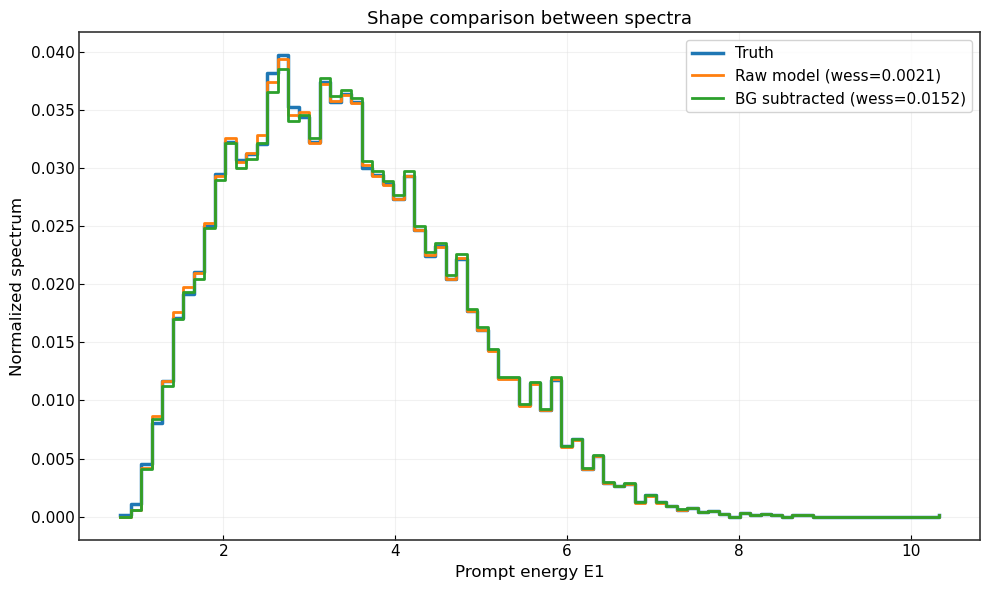

In [12]:
from scipy.stats import chisquare, wasserstein_distance


eps = 1e-12


hfp_norm = hfp / (hfp.sum() + eps)

ht_norm  = ht / (ht.sum() + eps)
hp_norm  = hp / (hp.sum() + eps)


signal_sub_pos = np.clip(signal_sub, 0, None)
hs_norm  = signal_sub_pos / (signal_sub_pos.sum() + eps)


# errore poissoniano sul truth normalizzato
sigma_ht = np.sqrt(ht + eps) / (ht.sum() + eps)

# chi2 modello raw
chi2_raw = np.sum(((hp_norm - ht_norm) ** 2) / (sigma_ht**2 + eps))

# chi2 background-subtracted
chi2_sub = np.sum( ((hs_norm - ht_norm) ** 2) / (sigma_ht**2 + eps))

ndof = len(ht_norm) - 1

red_chi2_raw = chi2_raw / ndof
red_chi2_sub = chi2_sub / ndof


wd_raw = wasserstein_distance(bin_centers, bin_centers, u_weights=ht_norm, v_weights=hp_norm)
wd_sub = wasserstein_distance(bin_centers, bin_centers, u_weights=ht_norm, v_weights=hs_norm)


cos_raw = np.dot(ht_norm, hp_norm) / (np.linalg.norm(ht_norm) * np.linalg.norm(hp_norm) + eps)
cos_sub = np.dot(ht_norm, hs_norm) / (np.linalg.norm(ht_norm) * np.linalg.norm(hs_norm) + eps)


kl_raw = np.sum(ht_norm * np.log((ht_norm + eps) / (hp_norm + eps)))
kl_sub = np.sum(ht_norm * np.log((ht_norm + eps) / (hs_norm + eps)))


print("\nRAW MODEL SELECTION vs TRUTH")
print(f"Degrees of freedom       : {ndof:.4f}")

print(f"Reduced Chi2        : {red_chi2_raw:.4f}")
print(f"Wasserstein distance: {wd_raw:.4f}")
print(f"Cosine similarity   : {cos_raw:.6f}")
print(f"KL divergence       : {kl_raw:.6f}")


print("\nBG SUBTRACTED vs TRUTH")
print(f"Reduced Chi2        : {red_chi2_sub:.4f}")
print(f"Wasserstein distance: {wd_sub:.4f}")
print(f"Cosine similarity   : {cos_sub:.6f}")
print(f"KL divergence       : {kl_sub:.6f}")


plt.figure(figsize=(10,6))

plt.step(bins[:-1],ht_norm,where="post",lw=2.5,label="Truth",)

plt.step(bins[:-1],hp_norm,where="post",lw=2,label=f"Raw model (wess={wd_raw:.4f})",)

plt.step(bins[:-1], hs_norm, where="post", lw=2, label=f"BG subtracted (wess={wd_sub:.4f})",)
#plt.step(bins[:-1], hfp_norm, where="post", lw=2, label=f"Fake positive",)

plt.xlabel("Prompt energy E1")
plt.ylabel("Normalized spectrum")
plt.title("Shape comparison between spectra")
plt.grid(alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\nicol\AppData\Local\Temp\ipykernel_20732\3569786530.py:1: RuntimeWarning: invalid value encountered in divide
  eff = signal_sub_pos/ht
C:\Users\nicol\AppData\Local\Temp\ipykernel_20732\3569786530.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


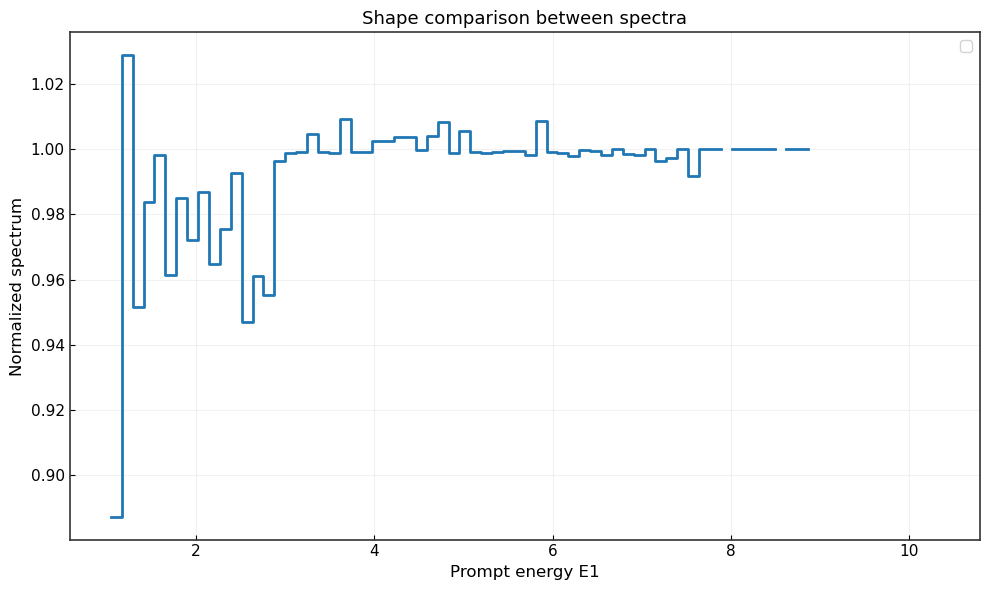

In [13]:
eff = signal_sub_pos/ht
plt.figure(figsize=(10,6))

plt.step(bins[2:-1], eff[2:], where="post", lw=2,)
plt.xlabel("Prompt energy E1")
plt.ylabel("Normalized spectrum")
plt.title("Shape comparison between spectra")
plt.grid(alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

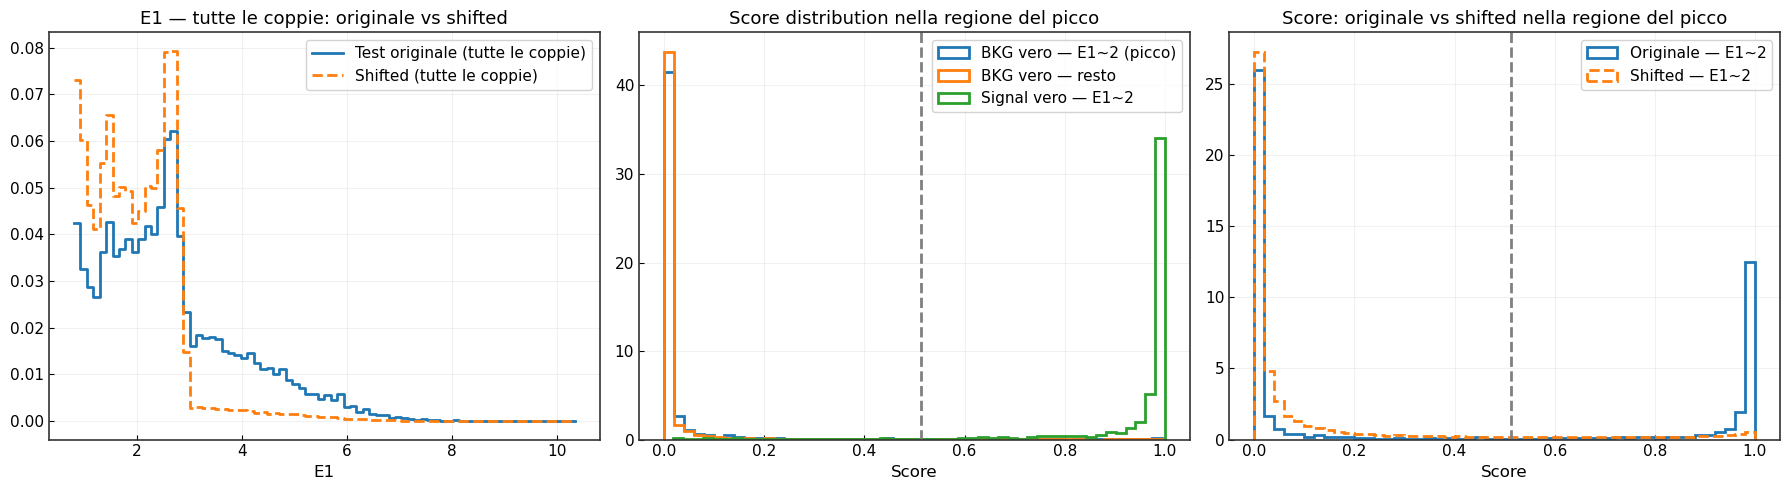

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# distribuzione E1 di TUTTE le coppie (non solo selezionate)
h_orig_all,  _ = np.histogram(test["E1"],  bins=bins)
h_shift_all, _ = np.histogram(prova["E1"], bins=bins)

ax = axes[0]
ax.step(bins[:-1], h_orig_all  / h_orig_all.sum(),  where="post", lw=2, label="Test originale (tutte le coppie)")
ax.step(bins[:-1], h_shift_all / h_shift_all.sum(), where="post", lw=2, linestyle="--", label="Shifted (tutte le coppie)")
ax.set_title("E1 — tutte le coppie: originale vs shifted")
ax.set_xlabel("E1"); ax.legend(); ax.grid(True, alpha=0.4)

# distribuzione score per le coppie a E1 ~ 2 vs resto
mask_peak  = (test["E1"] > 1.8) & (test["E1"] < 2.5)
mask_other = ~mask_peak

ax = axes[1]
ax.hist(prob[ mask_peak & (y_test==0)], bins=50, histtype="step", lw=2, density=True, label="BKG vero — E1~2 (picco)")
ax.hist(prob[~mask_peak & (y_test==0)], bins=50, histtype="step", lw=2, density=True, label="BKG vero — resto")
ax.hist(prob[ mask_peak & (y_test==1)], bins=50, histtype="step", lw=2, density=True, label="Signal vero — E1~2")
ax.axvline(threshold, color="gray", linestyle="--")
ax.set_title("Score distribution nella regione del picco")
ax.set_xlabel("Score"); ax.legend(); ax.grid(True, alpha=0.4)

# confronto score nel shifted vs originale nella regione del picco
mask_peak_prova = (prova["E1"] > 1.8) & (prova["E1"] < 2.5)

ax = axes[2]
ax.hist(prob[mask_peak],  bins=50, histtype="step", lw=2, density=True, label="Originale — E1~2")
ax.hist(prob2[mask_peak_prova], bins=50, histtype="step", lw=2, density=True, linestyle="--", label="Shifted — E1~2")
ax.axvline(threshold, color="gray", linestyle="--")
ax.set_title("Score: originale vs shifted nella regione del picco")
ax.set_xlabel("Score"); ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


# FRACTION TESTS

FPR_shift  = 0.0496
FPR_test   = 0.0178
Correction = 0.3583

Running closure test...

Signal fraction = 0.01
Signal fraction = 0.02
Signal fraction = 0.05
Signal fraction = 0.10
Signal fraction = 0.20
Signal fraction = 0.30
Signal fraction = 0.50
Signal fraction = 0.70
Signal fraction = 0.90


,true_fraction,raw_mean,raw_std,sub_mean,sub_std,raw_bias,sub_bias
0,0.01,0.027350,0.000282,0.009765,0.000314,0.017350,-0.000235
1,0.02,0.036978,0.000303,0.019570,0.000304,0.016978,-0.000430
2,0.05,0.065832,0.000374,0.048957,0.000371,0.015832,-0.001043
3,0.10,0.113920,0.000571,0.097933,0.000539,0.013920,-0.002067
4,0.20,0.210154,0.000643,0.195944,0.000636,0.010154,-0.004056
5,0.30,0.306302,0.000686,0.293868,0.000657,0.006302,-0.006132
6,0.50,0.498706,0.000992,0.489825,0.000987,-0.001294,-0.010175
7,0.70,0.691278,0.000820,0.685949,0.000811,-0.008722,-0.014051
8,0.90,0.883820,0.000469,0.882044,0.000470,-0.016180,-0.017956


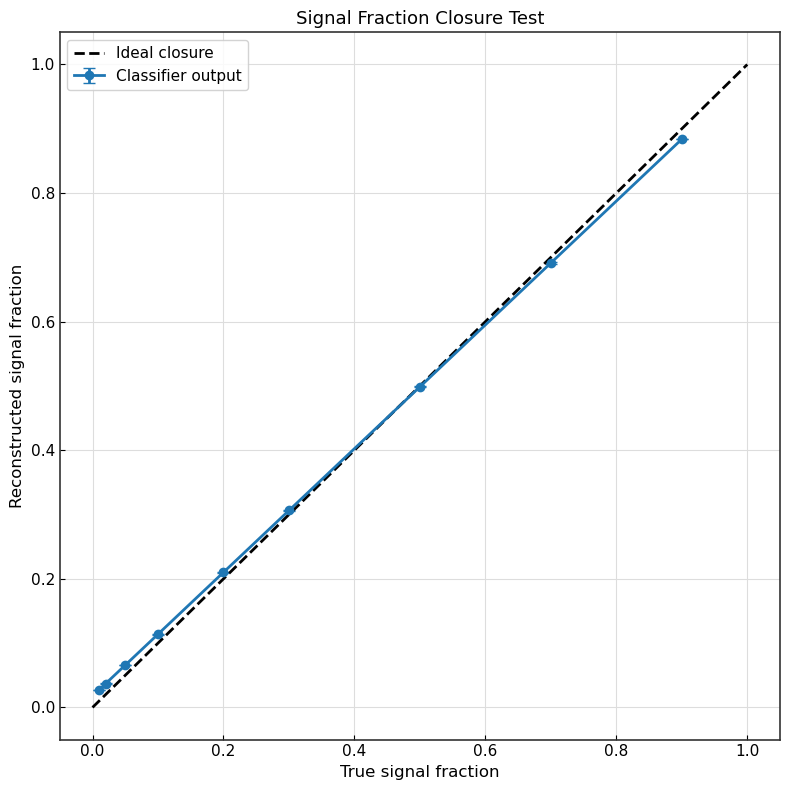

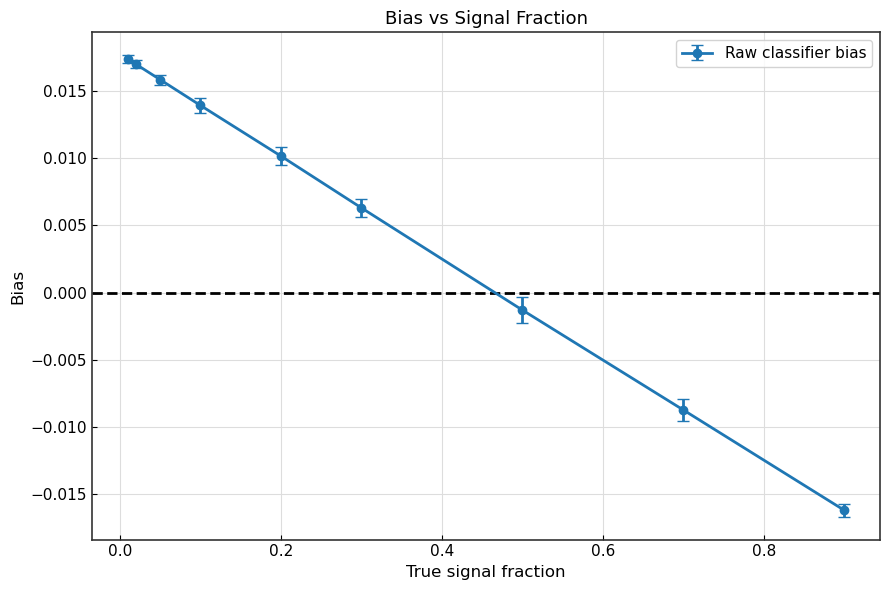

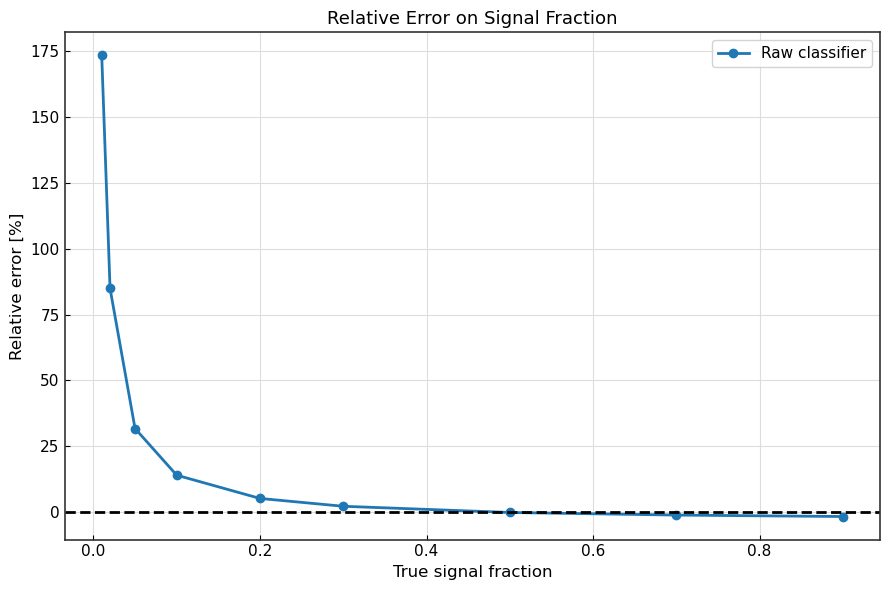

MEAN ABSOLUTE BIAS
Classifier:       0.011859111111111105
Shift-subtracted: 0.006238427904361684


In [20]:
fractions = [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]

N_EVENTS = 10000
N_TRIALS = 50

signal_df     = test[test["target"] == 1].copy()
background_df = test[test["target"] == 0].copy()

prova = pl.read_parquet("full_test2.parquet").to_pandas()
shift_ids_all = sorted(prova["shift_id"].unique())
if 2 in shift_ids_all:
    shift_ids_all.remove(2)

prova_by_shift = {sid: prova[prova["shift_id"] == sid].reset_index(drop=True) for sid in shift_ids_all}

# Stima FPR_shift: tasso medio di selezione sui dataset shiftati (background puro)
fpr_shift_list = []
for sid, shifted_df in prova_by_shift.items():
    X_s, _ = split_shift(shifted_df, drop_extra=ENERGY_FEATURES)
    p_s = final_model.predict_proba(X_s)[:, 1]
    fpr_shift_list.append(np.sum(p_s > threshold) / len(shifted_df))
FPR_SHIFT = np.mean(fpr_shift_list)

# Stima FPR_test: tasso di selezione sul background puro del test
# Usiamo tutto il background disponibile per una stima stabile
X_bkg_all, _ = split_xy(background_df, drop_extra=ENERGY_FEATURES)
p_bkg_all = final_model.predict_proba(X_bkg_all)[:, 1]
FPR_TEST = np.sum(p_bkg_all > threshold) / len(background_df)

# Fattore di correzione: quanto il modello "sovra-seleziona" sullo shift vs background reale
CORRECTION_FACTOR = FPR_TEST / FPR_SHIFT

print(f"FPR_shift  = {FPR_SHIFT:.4f}")
print(f"FPR_test   = {FPR_TEST:.4f}")
print(f"Correction = {CORRECTION_FACTOR:.4f}")

closure_results = []
print("\nRunning closure test...\n")

for frac in fractions:
    print(f"Signal fraction = {frac:.2f}")

    raw_fractions        = []
    subtracted_fractions = []

    for trial in range(N_TRIALS):
        n_sig = int(N_EVENTS * frac)
        n_bkg = N_EVENTS - n_sig

        sig_sample = signal_df.sample(n=n_sig, replace=len(signal_df) < n_sig, random_state=trial)
        bkg_sample = background_df.sample(n=n_bkg, replace=len(background_df) < n_bkg, random_state=trial)
        subset = pd.concat([sig_sample, bkg_sample], ignore_index=True)
        subset = subset.sample(frac=1, random_state=trial).reset_index(drop=True)

        X_sub, _ = split_xy(subset, drop_extra=ENERGY_FEATURES)
        prob_sub  = final_model.predict_proba(X_sub)[:, 1]
        pred_signal = np.sum(prob_sub > threshold)
        raw_fractions.append(pred_signal / len(subset))
        shift_signal_rates = []
        for sid, shifted_full in prova_by_shift.items():
            shifted_sample = shifted_full.sample(
                n=min(N_EVENTS, len(shifted_full)),
                replace=len(shifted_full) < N_EVENTS,
                random_state=trial
            )
            X_shift, _ = split_shift(shifted_sample, drop_extra=ENERGY_FEATURES)
            prob_shift = final_model.predict_proba(X_shift)[:, 1]
        
            # tasso di selezione sul fondo shiftato, non conteggio assoluto
            rate = np.sum(prob_shift > threshold) / len(shifted_sample)
            shift_signal_rates.append(rate)
        
        mean_shift_rate = np.mean(shift_signal_rates)
        
        # scala il tasso per il numero VERO di eventi di fondo in questo subset (n_bkg),
        # non per N_EVENTS fisso
        expected_bkg_selected = CORRECTION_FACTOR * mean_shift_rate * n_bkg
        
        signal_estimate = max(pred_signal - expected_bkg_selected, 0)
        subtracted_fractions.append(signal_estimate / len(subset))
                

    closure_results.append({
        "true_fraction": frac,
        "raw_mean":  np.mean(raw_fractions),
        "raw_std":   np.std(raw_fractions),
        "sub_mean":  np.mean(subtracted_fractions),
        "sub_std":   np.std(subtracted_fractions),
        "raw_bias":  np.mean(raw_fractions)        - frac,
        "sub_bias":  np.mean(subtracted_fractions) - frac,
    })

results_df = pd.DataFrame(closure_results)
display(results_df)

plt.figure(figsize=(8, 8))
plt.errorbar(results_df["true_fraction"], results_df["raw_mean"],
             yerr=results_df["raw_std"], marker="o", linewidth=2, capsize=4, label="Classifier output")
#plt.errorbar(results_df["true_fraction"], results_df["sub_mean"],             yerr=results_df["sub_std"], marker="s", linewidth=2, capsize=4, label="Shift-subtracted")
plt.plot([0, 1], [0, 1], "--", color="black", label="Ideal closure")
plt.xlabel("True signal fraction"); plt.ylabel("Reconstructed signal fraction")
plt.title("Signal Fraction Closure Test"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 6))
plt.errorbar(results_df["true_fraction"], results_df["raw_bias"],
             yerr=results_df["raw_std"], marker="o", linewidth=2, capsize=4, label="Raw classifier bias")
#plt.errorbar(results_df["true_fraction"], results_df["sub_bias"],             yerr=results_df["sub_std"], marker="s", linewidth=2, capsize=4, label="Shift-subtracted bias")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("True signal fraction"); plt.ylabel("Bias")
plt.title("Bias vs Signal Fraction"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

results_df["raw_rel_error"] = (results_df["raw_mean"] - results_df["true_fraction"]) / results_df["true_fraction"]
results_df["sub_rel_error"] = (results_df["sub_mean"] - results_df["true_fraction"]) / results_df["true_fraction"]

plt.figure(figsize=(9, 6))
plt.plot(results_df["true_fraction"], 100 * results_df["raw_rel_error"],
         marker="o", linewidth=2, label="Raw classifier")
#plt.plot(results_df["true_fraction"], 100 * results_df["sub_rel_error"], marker="s", linewidth=2, label="Shift-subtracted")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("True signal fraction"); plt.ylabel("Relative error [%]")
plt.title("Relative Error on Signal Fraction"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

print("MEAN ABSOLUTE BIAS")
print("Classifier:      ", np.mean(np.abs(results_df["raw_bias"])))
print("Shift-subtracted:", np.mean(np.abs(results_df["sub_bias"])))

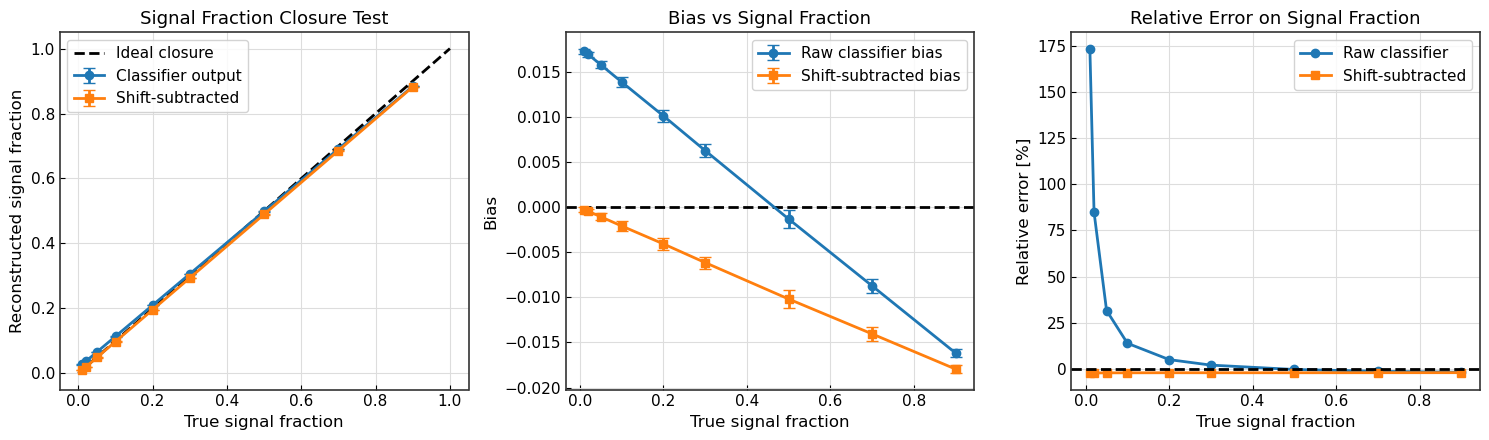

MEAN ABSOLUTE BIAS
Classifier:       0.011859111111111105
Shift-subtracted: 0.006238427904361684


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo dei dati (mantenuto prima dei grafici)
results_df["raw_rel_error"] = (results_df["raw_mean"] - results_df["true_fraction"]) / results_df["true_fraction"]
results_df["sub_rel_error"] = (results_df["sub_mean"] - results_df["true_fraction"]) / results_df["true_fraction"]

# 2. Creazione dell'unica figura compatta (1 riga, 3 colonne)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Sotto-grafico 1: Closure Test ---
axs[0].errorbar(results_df["true_fraction"], results_df["raw_mean"],
                yerr=results_df["raw_std"], marker="o", linewidth=2, capsize=4, label="Classifier output")
axs[0].errorbar(results_df["true_fraction"], results_df["sub_mean"], yerr=results_df["sub_std"], marker="s", linewidth=2, capsize=4, label="Shift-subtracted")
axs[0].plot([0, 1], [0, 1], "--", color="black", label="Ideal closure")
axs[0].set_xlabel("True signal fraction")
axs[0].set_ylabel("Reconstructed signal fraction")
axs[0].set_title("Signal Fraction Closure Test")
axs[0].grid(True)
axs[0].legend()

# --- Sotto-grafico 2: Bias ---
axs[1].errorbar(results_df["true_fraction"], results_df["raw_bias"],
                yerr=results_df["raw_std"], marker="o", linewidth=2, capsize=4, label="Raw classifier bias")
axs[1].errorbar(results_df["true_fraction"], results_df["sub_bias"], yerr=results_df["sub_std"], marker="s", linewidth=2, capsize=4, label="Shift-subtracted bias")
axs[1].axhline(0, color="black", linestyle="--")
axs[1].set_xlabel("True signal fraction")
axs[1].set_ylabel("Bias")
axs[1].set_title("Bias vs Signal Fraction")
axs[1].grid(True)
axs[1].legend()

# --- Sotto-grafico 3: Relative Error ---
axs[2].plot(results_df["true_fraction"], 100 * results_df["raw_rel_error"],
            marker="o", linewidth=2, label="Raw classifier")
axs[2].plot(results_df["true_fraction"], 100 * results_df["sub_rel_error"], marker="s", linewidth=2, label="Shift-subtracted")
axs[2].axhline(0, color="black", linestyle="--")
axs[2].set_xlabel("True signal fraction")
axs[2].set_ylabel("Relative error [%]")
axs[2].set_title("Relative Error on Signal Fraction")
axs[2].grid(True)
axs[2].legend()

# Ottimizzazione degli spazi e mostra la figura
plt.tight_layout()
plt.show()

# 3. Print finali dei risultati
print("MEAN ABSOLUTE BIAS")
print("Classifier:      ", np.mean(np.abs(results_df["raw_bias"])))
print("Shift-subtracted:", np.mean(np.abs(results_df["sub_bias"])))

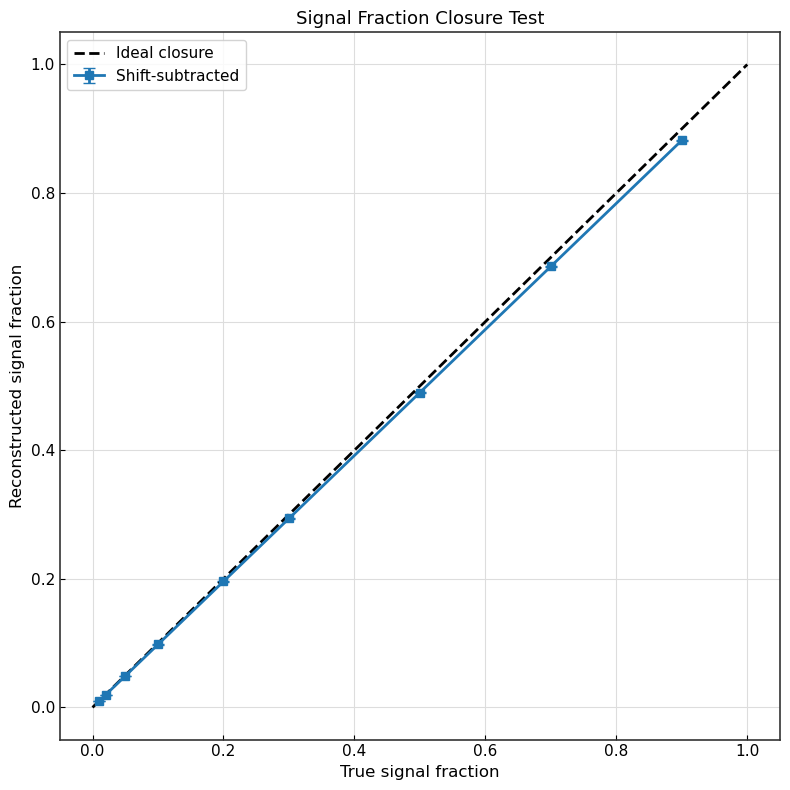

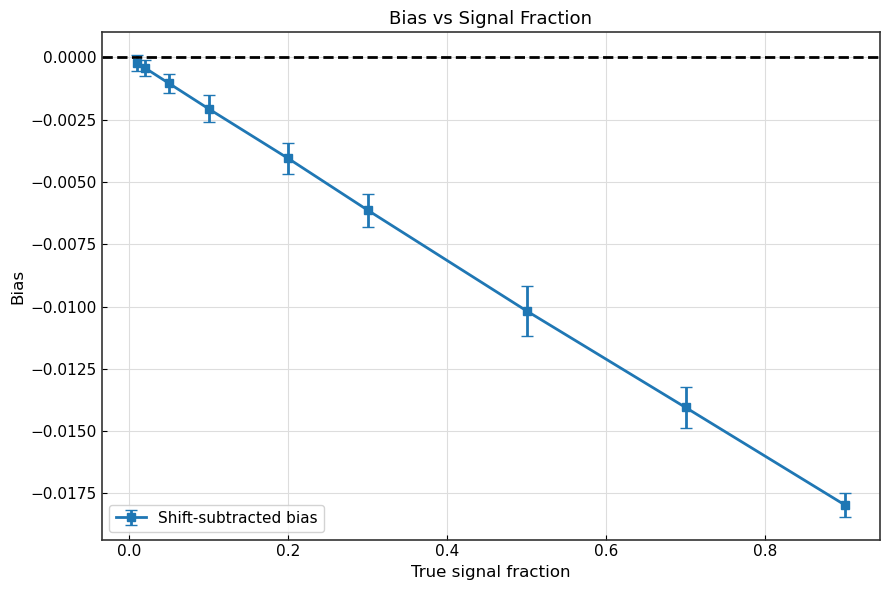

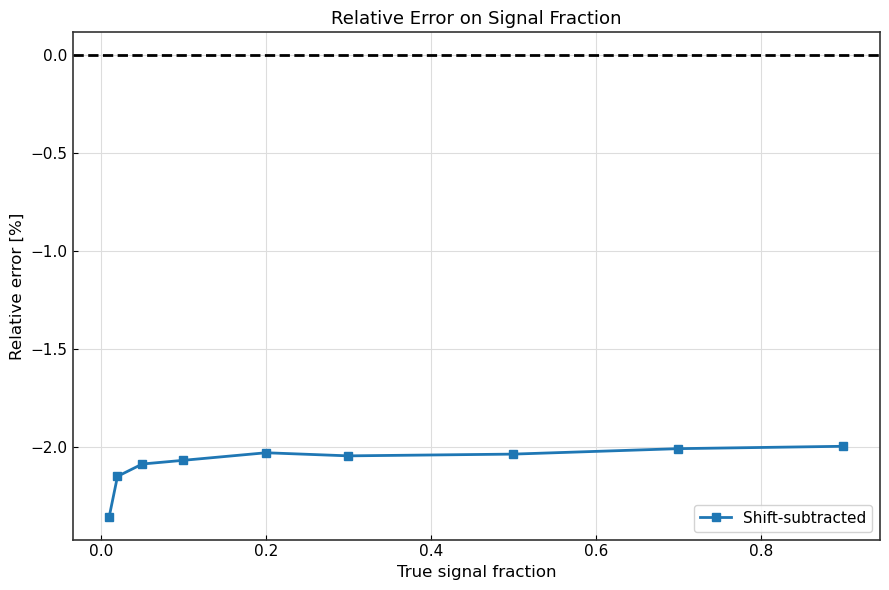

MEAN ABSOLUTE BIAS
Classifier:       0.011859111111111105
Shift-subtracted: 0.006238427904361684


In [22]:

plt.figure(figsize=(8, 8))
#plt.errorbar(results_df["true_fraction"], results_df["raw_mean"],            yerr=results_df["raw_std"], marker="o", linewidth=2, capsize=4, label="Classifier output")
plt.errorbar(results_df["true_fraction"], results_df["sub_mean"],             yerr=results_df["sub_std"], marker="s", linewidth=2, capsize=4, label="Shift-subtracted")
plt.plot([0, 1], [0, 1], "--", color="black", label="Ideal closure")
plt.xlabel("True signal fraction"); plt.ylabel("Reconstructed signal fraction")
plt.title("Signal Fraction Closure Test"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 6))
#plt.errorbar(results_df["true_fraction"], results_df["raw_bias"],             yerr=results_df["raw_std"], marker="o", linewidth=2, capsize=4, label="Raw classifier bias")
plt.errorbar(results_df["true_fraction"], results_df["sub_bias"],             yerr=results_df["sub_std"], marker="s", linewidth=2, capsize=4, label="Shift-subtracted bias")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("True signal fraction"); plt.ylabel("Bias")
plt.title("Bias vs Signal Fraction"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

results_df["raw_rel_error"] = (results_df["raw_mean"] - results_df["true_fraction"]) / results_df["true_fraction"]
results_df["sub_rel_error"] = (results_df["sub_mean"] - results_df["true_fraction"]) / results_df["true_fraction"]

plt.figure(figsize=(9, 6))
#plt.plot(results_df["true_fraction"], 100 * results_df["raw_rel_error"], marker="o", linewidth=2, label="Raw classifier")
plt.plot(results_df["true_fraction"], 100 * results_df["sub_rel_error"], marker="s", linewidth=2, label="Shift-subtracted")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("True signal fraction"); plt.ylabel("Relative error [%]")
plt.title("Relative Error on Signal Fraction"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

print("MEAN ABSOLUTE BIAS")
print("Classifier:      ", np.mean(np.abs(results_df["raw_bias"])))
print("Shift-subtracted:", np.mean(np.abs(results_df["sub_bias"])))

In [ ]:
# THETA ERROR

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt

THRESHOLD = 0.5          # soglia fissata
N_SHIFTS = 50            # numero time shifts
N_TOYS = 1000            # toy MC

E_BINS = np.linspace(0,12,60)

DM2 = 2.5e-3             # eV^2
BASELINE_NEAR = 400      # m
BASELINE_FAR  = 1600     # m


# ============================================================
# DATASET REALI
# ============================================================

near = pd.read_parquet("events_near.parquet")
far  = pd.read_parquet("events_far.parquet")


# ============================================================
# PREPROCESSING IDENTICO AL TRAIN
# ============================================================

FEATURES = FEATURES_USED      # deve essere la lista del training

X_near = near[FEATURES]
X_far  = far[FEATURES]


# ============================================================
# MODEL INFERENCE
# ============================================================

score_near = model.predict_proba(X_near)[:,1]
score_far  = model.predict_proba(X_far)[:,1]


near["score"] = score_near
far["score"]  = score_far


# ============================================================
# THRESHOLD
# ============================================================

near_sel = near[near.score > THRESHOLD].copy()
far_sel  = far[far.score > THRESHOLD].copy()


print("Selected near:",len(near_sel))
print("Selected far :",len(far_sel))



# ============================================================
# CALIBRAZIONE S/B
# ottenuta dal validation set etichettato
# ============================================================

def calibrate_SB(df, R_SB):
    N=len(df)

    S = N*R_SB/(1+R_SB)
    B = N/(1+R_SB)

    return S,B



# valori ottenuti dalla calibrazione precedente
R_NEAR = 2.0
R_FAR  = 0.8


S_near,B_near = calibrate_SB(
    near_sel,
    R_NEAR
)

S_far,B_far = calibrate_SB(
    far_sel,
    R_FAR
)


print("Near S/B",S_near/B_near)
print("Far S/B ",S_far/B_far)



# ============================================================
# TIME SHIFT BACKGROUND
# ============================================================

def time_shift_background(df, nshift=50):

    backgrounds=[]

    t=df["time"].values

    for k in range(nshift):

        shift=np.random.randint(
            1,
            len(df)
        )

        shifted=np.roll(t,shift)

        tmp=df.copy()
        tmp["time_shift"]=shifted

        backgrounds.append(tmp)

    return backgrounds



shifted_far=time_shift_background(
    far_sel,
    N_SHIFTS
)



# ============================================================
# HISTOGRAMMI
# ============================================================

def hist_energy(df):

    return np.histogram(
        df["E_sum"],
        bins=E_BINS
    )[0]


N_far_obs = hist_energy(far_sel)


B_shift=[]

for b in shifted_far:
    B_shift.append(
        hist_energy(b)
    )


B_shift=np.array(B_shift)


B_est=B_shift.mean(axis=0)

S_est=N_far_obs-B_est


# errore shift

sigma_shift=B_shift.std(axis=0)/np.sqrt(N_SHIFTS)


sigma_stat=np.sqrt(
    N_far_obs
)


sigma_total=np.sqrt(
    sigma_stat**2+
    sigma_shift**2
)



plt.errorbar(
    E_BINS[:-1],
    S_est,
    yerr=sigma_total,
    fmt="."
)

plt.xlabel("Energy")
plt.ylabel("Signal")
plt.show()



# ============================================================
# OSCILLAZIONE 2 FLAVOUR
# ============================================================

def Pee(E,theta13,L):

    phase=1.27*DM2*L/E

    return (
        1
        -
        np.sin(2*theta13)**2
        *
        np.sin(phase)**2
    )



# ============================================================
# MODEL SPETTRALE
# ============================================================

E_centers=0.5*(E_BINS[:-1]+E_BINS[1:])


# spettro senza oscillazione
# ottenuto dal near detector scalato

N0 = hist_energy(near_sel)

scale = len(far_sel)/len(near_sel)

N0_far = N0*scale



def prediction(theta):

    return (
        N0_far *
        Pee(
            E_centers,
            theta,
            BASELINE_FAR
        )
    )



# ============================================================
# FIT theta13
# ============================================================

def chi2(theta):

    pred=prediction(theta[0])

    return np.sum(
        (S_est-pred)**2 /
        sigma_total**2
    )



fit=minimize(
    chi2,
    x0=[0.15],
    bounds=[(0,0.5)]
)


theta_fit=fit.x[0]


print(
    "theta13 fitted:",
    theta_fit
)



# ============================================================
# TOY MC ERROR PROPAGATION
# ============================================================

theta_toys=[]


for i in range(N_TOYS):

    # variazione statistica

    toy_obs=np.random.poisson(
        N_far_obs
    )


    # calibrazione SB

    Rtoy_NEAR=np.random.normal(
        R_NEAR,
        0.05*R_NEAR
    )

    Rtoy_FAR=np.random.normal(
        R_FAR,
        0.05*R_FAR
    )


    # shift uncertainty

    toy_B=np.random.normal(
        B_est,
        sigma_shift
    )


    toy_S=toy_obs-toy_B


    def toy_chi2(theta):

        pred=N0_far*Pee(
            E_centers,
            theta[0],
            BASELINE_FAR
        )

        return np.sum(
            (toy_S-pred)**2 /
            sigma_total**2
        )


    res=minimize(
        toy_chi2,
        [theta_fit],
        bounds=[(0,0.5)]
    )


    theta_toys.append(
        res.x[0]
    )



theta_toys=np.array(theta_toys)



print(
    "theta13 =",
    theta_fit,
    "+/-",
    theta_toys.std()
)


plt.hist(
    theta_toys,
    bins=50
)

plt.xlabel("theta13")
plt.ylabel("Toys")
plt.show()

# Fractions tests with correction

FPR_shift          = 0.0969
FPR_test           = 0.0380
TPR                = 0.9725
Correction factor  = 0.3927
Efficiency (TPR-FPR) = 0.9344

Running closure test...

Signal fraction = 0.01
Signal fraction = 0.02
Signal fraction = 0.05
Signal fraction = 0.10
Signal fraction = 0.20
Signal fraction = 0.30
Signal fraction = 0.50
Signal fraction = 0.70
Signal fraction = 0.90


,true_fraction,raw_mean,raw_std,sub_mean,sub_std,raw_bias,sub_bias
0,0.01,0.047378,0.000420,0.009986,0.000523,0.037378,-0.000014
1,0.02,0.056726,0.000477,0.019990,0.000588,0.036726,-0.000010
2,0.05,0.084720,0.000603,0.049948,0.000694,0.034720,-0.000052
3,0.10,0.131438,0.000826,0.099945,0.000952,0.031438,-0.000055
4,0.20,0.224956,0.000972,0.200026,0.001100,0.024956,0.000026
5,0.30,0.318394,0.001310,0.300021,0.001465,0.018394,0.000021
6,0.50,0.505368,0.001490,0.500116,0.001662,0.005368,0.000116
7,0.70,0.692026,0.001098,0.699874,0.001252,-0.007974,-0.000126
8,0.90,0.879002,0.000686,0.899971,0.000850,-0.020998,-0.000029


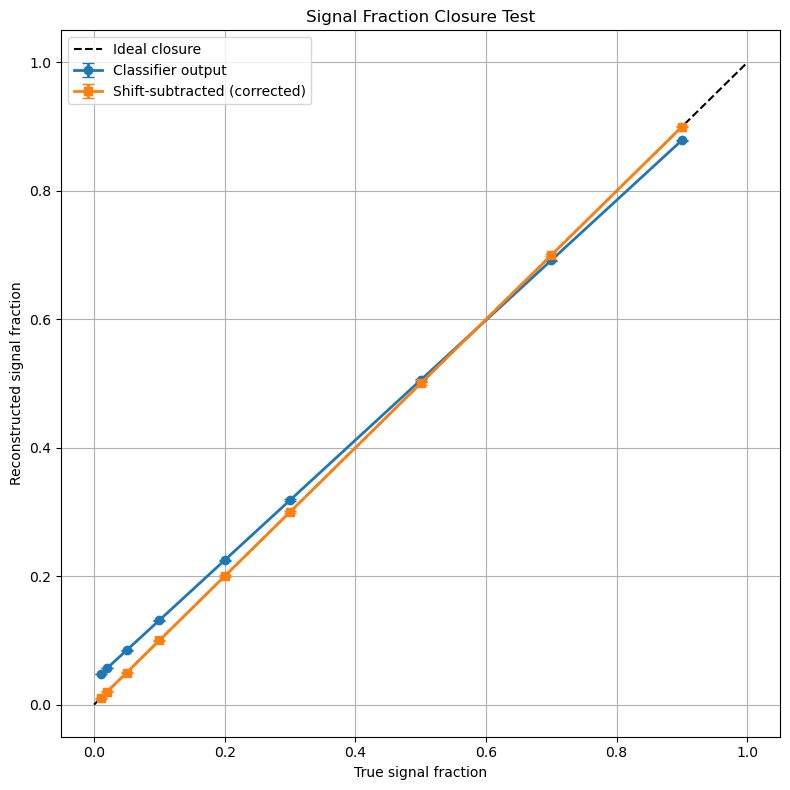

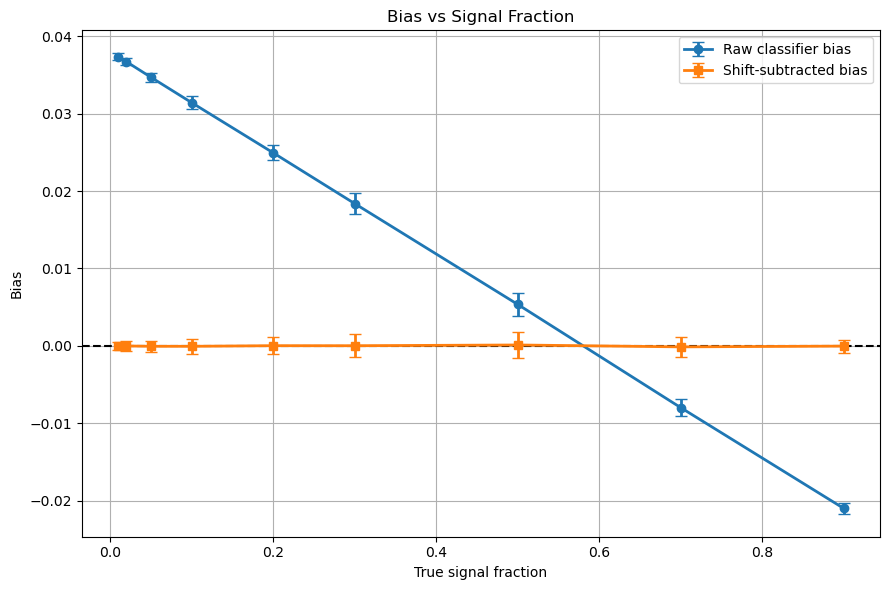

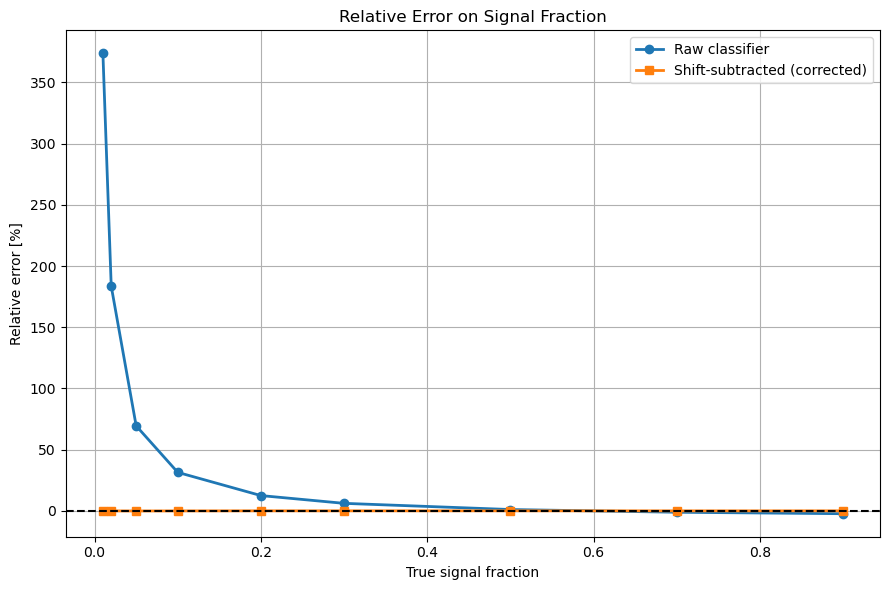

MEAN ABSOLUTE BIAS
Classifier:       0.02421688888888889
Shift-subtracted: 4.99283095379757e-05


In [32]:
fractions = [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]
N_EVENTS = 10000
N_TRIALS = 50

signal_df     = test[test["target"] == 1].copy()
background_df = test[test["target"] == 0].copy()

prova = pl.read_parquet("full_test2.parquet").to_pandas()
shift_ids_all = sorted(prova["shift_id"].unique())
if 2 in shift_ids_all:
    shift_ids_all.remove(2)

prova_by_shift = {sid: prova[prova["shift_id"] == sid].reset_index(drop=True) for sid in shift_ids_all}

# FPR_shift: tasso di selezione medio sui dataset shiftati (background puro per costruzione)
fpr_shift_list = []
for sid, shifted_df in prova_by_shift.items():
    X_s, _ = split_shift(shifted_df, drop_extra=ENERGY_FEATURES)
    p_s = final_model.predict_proba(X_s)[:, 1]
    fpr_shift_list.append(np.sum(p_s > threshold) / len(shifted_df))
FPR_SHIFT = np.mean(fpr_shift_list)

# FPR_test e TPR: stimati sul background e segnale puro del test
X_bkg_all, _ = split_xy(background_df, drop_extra=ENERGY_FEATURES)
p_bkg_all     = final_model.predict_proba(X_bkg_all)[:, 1]
FPR_TEST      = np.sum(p_bkg_all > threshold) / len(background_df)

X_sig_all, _ = split_xy(signal_df, drop_extra=ENERGY_FEATURES)
p_sig_all     = final_model.predict_proba(X_sig_all)[:, 1]
TPR           = np.sum(p_sig_all > threshold) / len(signal_df)

CORRECTION_FACTOR = FPR_TEST / FPR_SHIFT
EFFICIENCY        = TPR - FPR_TEST   # fattore per de-biasare la stima

print(f"FPR_shift          = {FPR_SHIFT:.4f}")
print(f"FPR_test           = {FPR_TEST:.4f}")
print(f"TPR                = {TPR:.4f}")
print(f"Correction factor  = {CORRECTION_FACTOR:.4f}")
print(f"Efficiency (TPR-FPR) = {EFFICIENCY:.4f}")

closure_results = []
print("\nRunning closure test...\n")

for frac in fractions:
    print(f"Signal fraction = {frac:.2f}")

    raw_fractions        = []
    subtracted_fractions = []

    for trial in range(N_TRIALS):
        n_sig = int(N_EVENTS * frac)
        n_bkg = N_EVENTS - n_sig

        sig_sample = signal_df.sample(n=n_sig, replace=len(signal_df) < n_sig, random_state=trial)
        bkg_sample = background_df.sample(n=n_bkg, replace=len(background_df) < n_bkg, random_state=trial)
        subset = pd.concat([sig_sample, bkg_sample], ignore_index=True)
        subset = subset.sample(frac=1, random_state=trial).reset_index(drop=True)

        X_sub, _ = split_xy(subset, drop_extra=ENERGY_FEATURES)
        prob_sub  = final_model.predict_proba(X_sub)[:, 1]
        pred_signal = np.sum(prob_sub > threshold)
        raw_fractions.append(pred_signal / len(subset))

        shift_signal_counts = []
        for sid, shifted_full in prova_by_shift.items():
            shifted_sample = shifted_full.sample(
                n=min(N_EVENTS, len(shifted_full)),
                replace=len(shifted_full) < N_EVENTS,
                random_state=trial
            )
            X_shift, _ = split_shift(shifted_sample, drop_extra=ENERGY_FEATURES)
            prob_shift  = final_model.predict_proba(X_shift)[:, 1]
            shift_signal_counts.append(np.sum(prob_shift > threshold))

        mean_shift_signal = np.mean(shift_signal_counts)

        # Sottrazione corretta + correzione per efficienza
        net_signal = pred_signal - CORRECTION_FACTOR * mean_shift_signal
        signal_estimate = max(net_signal, 0) / (EFFICIENCY * len(subset))
        subtracted_fractions.append(signal_estimate)

    closure_results.append({
        "true_fraction": frac,
        "raw_mean":  np.mean(raw_fractions),
        "raw_std":   np.std(raw_fractions),
        "sub_mean":  np.mean(subtracted_fractions),
        "sub_std":   np.std(subtracted_fractions),
        "raw_bias":  np.mean(raw_fractions)        - frac,
        "sub_bias":  np.mean(subtracted_fractions) - frac,
    })

results_df = pd.DataFrame(closure_results)
display(results_df)

plt.figure(figsize=(8, 8))
plt.errorbar(results_df["true_fraction"], results_df["raw_mean"],
             yerr=results_df["raw_std"], marker="o", linewidth=2, capsize=4, label="Classifier output")
plt.errorbar(results_df["true_fraction"], results_df["sub_mean"],
             yerr=results_df["sub_std"], marker="s", linewidth=2, capsize=4, label="Shift-subtracted (corrected)")
plt.plot([0, 1], [0, 1], "--", color="black", label="Ideal closure")
plt.xlabel("True signal fraction"); plt.ylabel("Reconstructed signal fraction")
plt.title("Signal Fraction Closure Test"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 6))
plt.errorbar(results_df["true_fraction"], results_df["raw_bias"],
             yerr=results_df["raw_std"], marker="o", linewidth=2, capsize=4, label="Raw classifier bias")
plt.errorbar(results_df["true_fraction"], results_df["sub_bias"],
             yerr=results_df["sub_std"], marker="s", linewidth=2, capsize=4, label="Shift-subtracted bias")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("True signal fraction"); plt.ylabel("Bias")
plt.title("Bias vs Signal Fraction"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

results_df["raw_rel_error"] = (results_df["raw_mean"] - results_df["true_fraction"]) / results_df["true_fraction"]
results_df["sub_rel_error"] = (results_df["sub_mean"] - results_df["true_fraction"]) / results_df["true_fraction"]

plt.figure(figsize=(9, 6))
plt.plot(results_df["true_fraction"], 100 * results_df["raw_rel_error"],
         marker="o", linewidth=2, label="Raw classifier")
plt.plot(results_df["true_fraction"], 100 * results_df["sub_rel_error"],
         marker="s", linewidth=2, label="Shift-subtracted (corrected)")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("True signal fraction"); plt.ylabel("Relative error [%]")
plt.title("Relative Error on Signal Fraction"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

print("MEAN ABSOLUTE BIAS")
print("Classifier:      ", np.mean(np.abs(results_df["raw_bias"])))
print("Shift-subtracted:", np.mean(np.abs(results_df["sub_bias"])))


Fraction = 0.01

Fraction = 0.02

Fraction = 0.05

Fraction = 0.10

Fraction = 0.20

Fraction = 0.30

Fraction = 0.50

Fraction = 0.70

Fraction = 0.90


,fraction,chi2_raw,chi2_sub,wd_raw,wd_sub,cos_raw,cos_sub,kl_raw,kl_sub
0,0.01,1.580692e+08,2.654062e+07,1.302119,0.190549,0.572418,0.832231,0.855455,2.080298
1,0.02,6.957018e+07,3.263171e+06,1.053922,0.084206,0.695671,0.930821,0.486073,0.455368
2,0.05,2.033831e+07,5.222925e+04,0.684943,0.047500,0.858375,0.984745,0.204528,0.058963
3,0.10,6.648953e+06,8.526613e+03,0.417315,0.040375,0.944287,0.995176,0.088965,0.030059
4,0.20,1.533560e+06,3.190958e+02,0.219031,0.044864,0.984394,0.997964,0.034139,0.025610
5,0.30,4.900454e+05,1.815668e-01,0.137752,0.046601,0.993801,0.998523,0.017480,0.023362
6,0.50,6.972218e+04,2.545587e-01,0.062815,0.047835,0.998648,0.998874,0.005925,0.021676
7,0.70,3.941629e+03,3.736577e-01,0.027351,0.049728,0.999693,0.998937,0.001734,0.023339
8,0.90,7.486559e+01,4.850317e-01,0.009343,0.049421,0.999904,0.998986,0.000368,0.025454


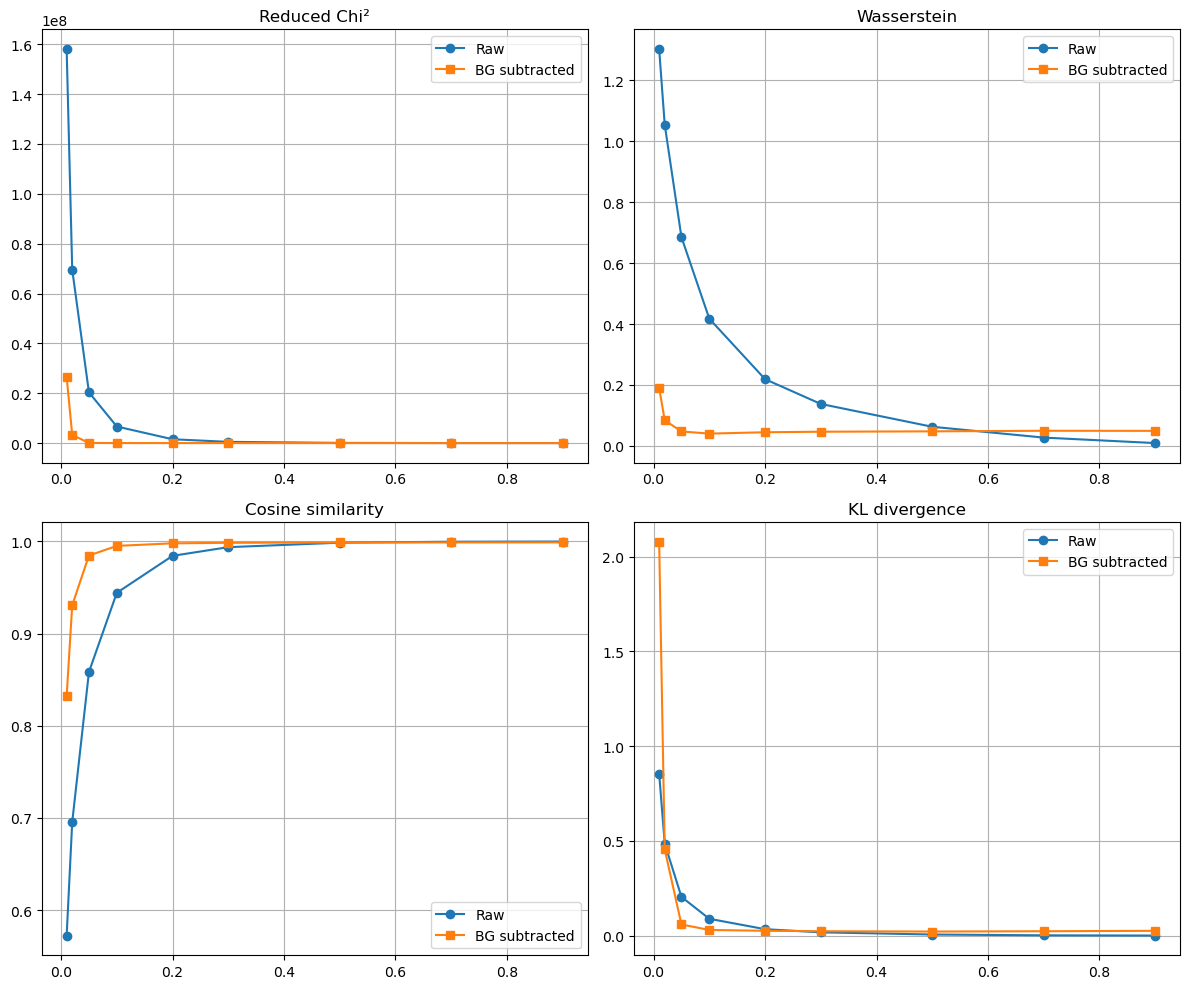


Average improvement (frazioni con stima affidabile):
Chi2   : 25206564.317213774
WD     : 0.3681680443516547
Cosine : 0.07656280540581853
KL     : -0.11660695326798774


In [34]:
from scipy.stats import wasserstein_distance

fractions = [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]
N_EVENTS = 10000
N_TRIALS = 20
eps = 1e-12

signal_df     = test[test["target"] == 1].copy()
background_df = test[test["target"] == 0].copy()

bins = np.linspace(
    min(test["E1"].min(), prova["E1"].min()),
    max(test["E1"].max(), prova["E1"].max()),
    80
)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Stessi fattori di correzione della cella 1 (ricalcolati se necessario)
# FPR_SHIFT, FPR_TEST, TPR, CORRECTION_FACTOR, EFFICIENCY devono essere già definiti.
# Se non lo sono, ricalcola:
if "CORRECTION_FACTOR" not in dir():
    fpr_shift_list = []
    for sid, shifted_df in prova_by_shift.items():
        X_s, _ = split_shift(shifted_df, drop_extra=ENERGY_FEATURES)
        p_s = final_model.predict_proba(X_s)[:, 1]
        fpr_shift_list.append(np.sum(p_s > threshold) / len(shifted_df))
    FPR_SHIFT = np.mean(fpr_shift_list)

    X_bkg_all, _ = split_xy(background_df, drop_extra=ENERGY_FEATURES)
    FPR_TEST = np.sum(final_model.predict_proba(X_bkg_all)[:, 1] > threshold) / len(background_df)

    X_sig_all, _ = split_xy(signal_df, drop_extra=ENERGY_FEATURES)
    TPR = np.sum(final_model.predict_proba(X_sig_all)[:, 1] > threshold) / len(signal_df)

    CORRECTION_FACTOR = FPR_TEST / FPR_SHIFT
    EFFICIENCY        = TPR - FPR_TEST

shape_results = []

for frac in fractions:
    print(f"\nFraction = {frac:.2f}")

    chi2_raw_list, chi2_sub_list = [], []
    wd_raw_list,   wd_sub_list   = [], []
    cos_raw_list,  cos_sub_list  = [], []
    kl_raw_list,   kl_sub_list   = [], []

    for trial in range(N_TRIALS):
        n_sig = int(N_EVENTS * frac)
        n_bkg = N_EVENTS - n_sig

        sig_sample = signal_df.sample(n=n_sig, replace=len(signal_df) < n_sig, random_state=trial)
        bkg_sample = background_df.sample(n=n_bkg, replace=len(background_df) < n_bkg, random_state=trial)
        subset = pd.concat([sig_sample, bkg_sample], ignore_index=True)
        subset = subset.sample(frac=1, random_state=trial).reset_index(drop=True)

        X_sub, _ = split_xy(subset, drop_extra=ENERGY_FEATURES)
        prob_sub  = final_model.predict_proba(X_sub)[:, 1]
        pred_mask = prob_sub > threshold

        # Istogramma ground truth (segnale vero) e predetto
        ht, _ = np.histogram(subset.loc[subset["target"] == 1, "E1"], bins=bins)
        hp, _ = np.histogram(subset.loc[pred_mask, "E1"],             bins=bins)

        # Background stimato: media degli shift campionati alla stessa dimensione
        shift_hists = []
        for sid, shifted_full in prova_by_shift.items():
            shifted_sample = shifted_full.sample(
                n=min(N_EVENTS, len(shifted_full)),
                replace=len(shifted_full) < N_EVENTS,
                random_state=trial
            )
            X_shift, _ = split_shift(shifted_sample, drop_extra=ENERGY_FEATURES)
            prob_shift  = final_model.predict_proba(X_shift)[:, 1]
            shift_mask  = prob_shift > threshold
            h_shift, _  = np.histogram(shifted_sample.loc[shift_mask, "E1"], bins=bins)
            shift_hists.append(h_shift)

        h_bkg_mean = np.array(shift_hists).mean(axis=0)

        # Sottrazione con correction factor, poi de-bias per efficienza
        # hp - CF * h_bkg stimola f*(TPR-FPR)*N eventi di segnale per bin
        # dividendo per EFFICIENCY si ottiene la stima non biasata dello spettro vero
        signal_sub_raw = hp - CORRECTION_FACTOR * h_bkg_mean
        signal_sub     = np.clip(signal_sub_raw, 0, None) / EFFICIENCY

        # Normalizza: confronta forme normalizzate
        ht_norm  = ht  / (ht.sum()  + eps)
        hp_norm  = hp  / (hp.sum()  + eps)
        hs_norm  = signal_sub / (signal_sub.sum() + eps)
        sigma_ht = np.sqrt(ht + eps) / (ht.sum() + eps)
        ndof     = len(ht_norm) - 1

        # Metriche — skip se hs_norm è degenere (tutto zero dopo clip)
        if signal_sub.sum() < 1:
            # stima non affidabile a questa frazione: registra NaN
            chi2_raw_list.append(np.nan)
            chi2_sub_list.append(np.nan)
            wd_raw_list.append(np.nan)
            wd_sub_list.append(np.nan)
            cos_raw_list.append(np.nan)
            cos_sub_list.append(np.nan)
            kl_raw_list.append(np.nan)
            kl_sub_list.append(np.nan)
            continue

        chi2_raw_list.append(np.sum(((hp_norm - ht_norm)**2) / (sigma_ht**2 + eps)) / ndof)
        chi2_sub_list.append(np.sum(((hs_norm - ht_norm)**2) / (sigma_ht**2 + eps)) / ndof)
        wd_raw_list.append(wasserstein_distance(bin_centers, bin_centers, u_weights=ht_norm, v_weights=hp_norm))
        wd_sub_list.append(wasserstein_distance(bin_centers, bin_centers, u_weights=ht_norm, v_weights=hs_norm))
        cos_raw_list.append(np.dot(ht_norm, hp_norm) / (np.linalg.norm(ht_norm) * np.linalg.norm(hp_norm) + eps))
        cos_sub_list.append(np.dot(ht_norm, hs_norm) / (np.linalg.norm(ht_norm) * np.linalg.norm(hs_norm) + eps))
        kl_raw_list.append(np.sum(ht_norm * np.log((ht_norm + eps) / (hp_norm + eps))))
        kl_sub_list.append(np.sum(ht_norm * np.log((ht_norm + eps) / (hs_norm + eps))))

    shape_results.append({
        "fraction": frac,
        "chi2_raw": np.nanmean(chi2_raw_list), "chi2_sub": np.nanmean(chi2_sub_list),
        "wd_raw":   np.nanmean(wd_raw_list),   "wd_sub":   np.nanmean(wd_sub_list),
        "cos_raw":  np.nanmean(cos_raw_list),  "cos_sub":  np.nanmean(cos_sub_list),
        "kl_raw":   np.nanmean(kl_raw_list),   "kl_sub":   np.nanmean(kl_sub_list),
    })

shape_df = pd.DataFrame(shape_results)
display(shape_df)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0,0].plot(shape_df["fraction"], shape_df["chi2_raw"], "o-", label="Raw")
ax[0,0].plot(shape_df["fraction"], shape_df["chi2_sub"], "s-", label="BG subtracted")
ax[0,0].set_title("Reduced Chi²"); ax[0,0].grid(); ax[0,0].legend()
ax[0,1].plot(shape_df["fraction"], shape_df["wd_raw"],  "o-", label="Raw")
ax[0,1].plot(shape_df["fraction"], shape_df["wd_sub"],  "s-", label="BG subtracted")
ax[0,1].set_title("Wasserstein"); ax[0,1].grid(); ax[0,1].legend()
ax[1,0].plot(shape_df["fraction"], shape_df["cos_raw"], "o-", label="Raw")
ax[1,0].plot(shape_df["fraction"], shape_df["cos_sub"], "s-", label="BG subtracted")
ax[1,0].set_title("Cosine similarity"); ax[1,0].grid(); ax[1,0].legend()
ax[1,1].plot(shape_df["fraction"], shape_df["kl_raw"],  "o-", label="Raw")
ax[1,1].plot(shape_df["fraction"], shape_df["kl_sub"],  "s-", label="BG subtracted")
ax[1,1].set_title("KL divergence"); ax[1,1].grid(); ax[1,1].legend()
plt.tight_layout(); plt.show()

print("\nAverage improvement (frazioni con stima affidabile):")
print("Chi2   :", np.nanmean(shape_df["chi2_raw"] - shape_df["chi2_sub"]))
print("WD     :", np.nanmean(shape_df["wd_raw"]   - shape_df["wd_sub"]))
print("Cosine :", np.nanmean(shape_df["cos_sub"]  - shape_df["cos_raw"]))
print("KL     :", np.nanmean(shape_df["kl_raw"]   - shape_df["kl_sub"]))

### just 1 shift background

In [141]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

prova = pl.read_parquet("full_test22.parquet").to_pandas()
prova = prova.sample(n=20167, random_state=42).reset_index(drop=True)
X_prova, y_prova = split_xy(prova, drop_extra=ENERGY_FEATURES)
prob2 = final_model.predict_proba(X_prova)[:, 1]

threshold = 0.5


true_prompt_mask = test["label1"] == 1
predicted_prompt_mask = prob > threshold

E_true      = test.loc[true_prompt_mask,                         "E1"]
E_predicted = test.loc[predicted_prompt_mask,                    "E1"]
E_tp        = test.loc[true_prompt_mask & predicted_prompt_mask, "E1"]

# ── Maschere prova (shifted) ──────────────────────────────────────────────────
true_prompt_mask2      = prova["label1"] == 1
predicted_prompt_mask2 = prob2 > threshold

E_true2      = prova.loc[true_prompt_mask2,                          "E1"]
E_predicted2 = prova.loc[predicted_prompt_mask2,                     "E1"]
E_tp2        = prova.loc[true_prompt_mask2 & predicted_prompt_mask2, "E1"]
#shifted_aux_pred = model.predict(x_shifted).flatten()
shifted_y_pred = np.zeros(len(prob2))
shifted_y_pred[prob2 >= 0.5] = 1
    
background = X_prova[shifted_y_pred == 1]['E1']


bins = np.linspace(
    min(test["E1"].min(), prova["E1"].min()),
    max(test["E1"].max(), prova["E1"].max()),
    80
)
hp, _ = np.histogram(E_predicted,bins=bins)

hb, _ = np.histogram(background,bins=bins)
ee=hp-hb
plt.figure(figsize=(9, 6))
plt.hist(E_true,      bins=bins, density=False, histtype="step",linewidth=2, color="steelblue", label="Ground truth (label1=1)")
plt.hist(E_predicted, bins=bins, density=False, histtype="step",linewidth=2, color="tomato",    label=f"Selezionati dal modello (score>{threshold})")
plt.hist(background,        bins=bins, density=False, histtype="step", linewidth=2, color="seagreen",  linestyle="--", label="True Positive (veri & selezionati)")
#plt.yscale("log")
plt.xlabel("Prompt energy E1")
plt.ylabel("Normalized counts")
plt.title("Spettro energia: ground truth vs riconoscimento classificatore")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()
plt.figure(figsize=(9, 6))
plt.hist(E_true,      bins=bins, density=False, histtype="step",linewidth=2, color="steelblue", label="Ground truth (label1=1)")
plt.hist(ee,        bins=bins, density=False, histtype="step", linewidth=2, color="seagreen",  linestyle="--", label="True Positive (veri & selezionati)")
#plt.yscale("log")
plt.xlabel("Prompt energy E1")
plt.ylabel("Normalized counts")
plt.title("Spettro energia: ground truth vs riconoscimento classificatore")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

y_pred  = (prob  > threshold).astype(int)
y_pred2 = (prob2 > threshold).astype(int)

cm  = confusion_matrix(y_test,  y_pred)
cm2 = confusion_matrix(y_prova, y_pred2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm_i, title in zip(axes,
                            [cm, cm2],
                            ["Confusion Matrix — Test originale",
                             "Confusion Matrix — Shifted dataset"]):
    ConfusionMatrixDisplay(cm_i, display_labels=["Background", "Signal"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{title} (thr={threshold})")

plt.tight_layout()
plt.show()

# ── Metriche finali ───────────────────────────────────────────────────────────
for label, cm_i in [("TEST originale", cm), ("PROVA shifted", cm2)]:
    tn, fp, fn, tp_val = cm_i.ravel()
    print(f"\n── {label} ──")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp_val}")
    print(f"  Precision : {tp_val/(tp_val+fp):.3f}")
    print(f"  Recall    : {tp_val/(tp_val+fn):.3f}")
    print(f"  F1        : {2*tp_val/(2*tp_val+fp+fn):.3f}")

KeyError: 'E1'

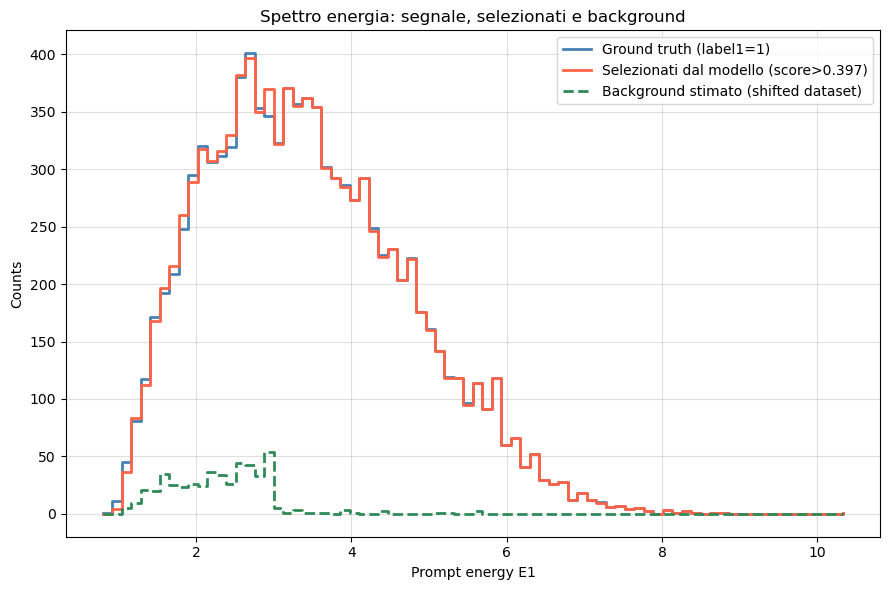

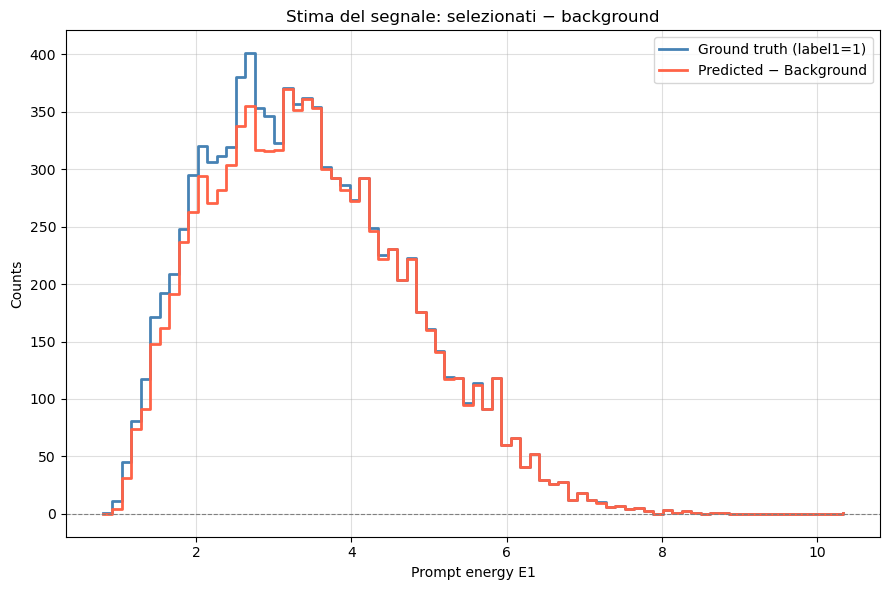

In [106]:
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width   = bins[1:] - bins[:-1]

hp, _ = np.histogram(E_predicted, bins=bins)
hb, _ = np.histogram(background,  bins=bins)
ht, _ = np.histogram(E_true,      bins=bins)

ee = hp - hb  # predicted - background = stima del segnale

plt.figure(figsize=(9, 6))
plt.step(bins[:-1], ht, where="post", linewidth=2, color="steelblue", label="Ground truth (label1=1)")
plt.step(bins[:-1], hp, where="post", linewidth=2, color="tomato",    label=f"Selezionati dal modello (score>{threshold})")
plt.step(bins[:-1], hb, where="post", linewidth=2, color="seagreen",  linestyle="--", label="Background stimato (shifted dataset)")
plt.xlabel("Prompt energy E1")
plt.ylabel("Counts")
plt.title("Spettro energia: segnale, selezionati e background")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot predicted - background ───────────────────────────────────────────────
plt.figure(figsize=(9, 6))
plt.step(bins[:-1], ht, where="post", linewidth=2, color="steelblue", label="Ground truth (label1=1)")
plt.step(bins[:-1], ee, where="post", linewidth=2, color="tomato",    label="Predicted − Background")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("Prompt energy E1")
plt.ylabel("Counts")
plt.title("Stima del segnale: selezionati − background")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

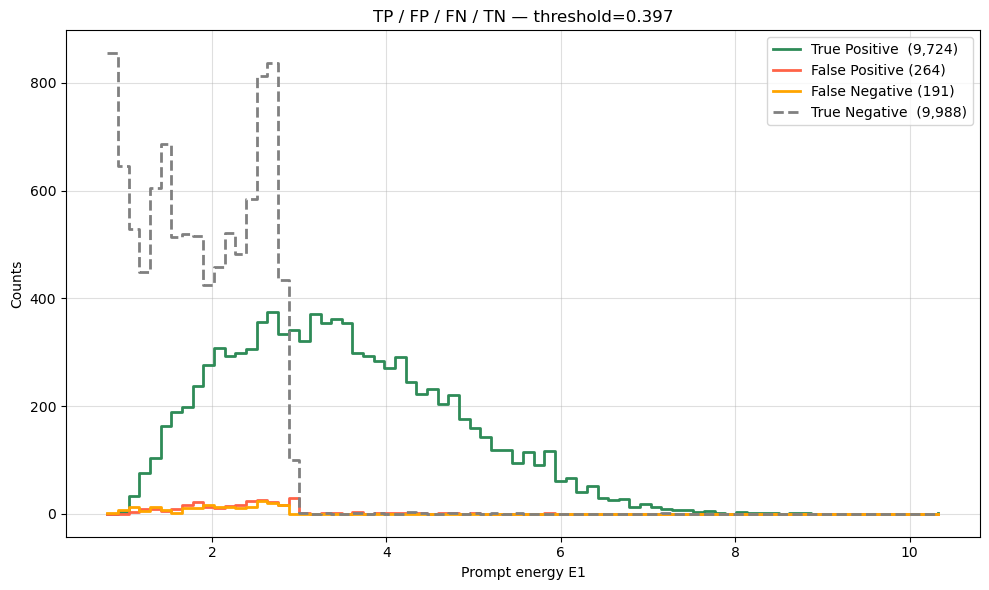

In [107]:
true_mask = y_test == 1
pred_mask = y_pred == 1

E_tp = test.loc[ true_mask &  pred_mask, "E1"]  # segnale vero, classificato segnale
E_fp = test.loc[~true_mask &  pred_mask, "E1"]  # background vero, classificato segnale
E_fn = test.loc[ true_mask & ~pred_mask, "E1"]  # segnale vero, classificato background
E_tn = test.loc[~true_mask & ~pred_mask, "E1"]  # background vero, classificato background

bins = np.linspace(test["E1"].min(), test["E1"].max(), 80)

h_tp, _ = np.histogram(E_tp, bins=bins)
h_fp, _ = np.histogram(E_fp, bins=bins)
h_fn, _ = np.histogram(E_fn, bins=bins)
h_tn, _ = np.histogram(E_tn, bins=bins)

plt.figure(figsize=(10, 6))
plt.step(bins[:-1], h_tp, where="post", linewidth=2, color="seagreen", label=f"True Positive  ({len(E_tp):,})")
plt.step(bins[:-1], h_fp, where="post", linewidth=2, color="tomato",   label=f"False Positive ({len(E_fp):,})")
plt.step(bins[:-1], h_fn, where="post", linewidth=2, color="orange",   label=f"False Negative ({len(E_fn):,})")
plt.step(bins[:-1], h_tn, where="post", linewidth=2, color="gray",     label=f"True Negative  ({len(E_tn):,})", linestyle="--")
plt.xlabel("Prompt energy E1")
plt.ylabel("Counts")
plt.title(f"TP / FP / FN / TN — threshold={threshold}")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Threshold choice

We want to find the best threshold that optimize the distiontion between background and signal.

Then we can choose an amount of signal over the total that we want and based on that have new values for the threshold.

Best threshold (F1): 0.920  →  F1=0.958


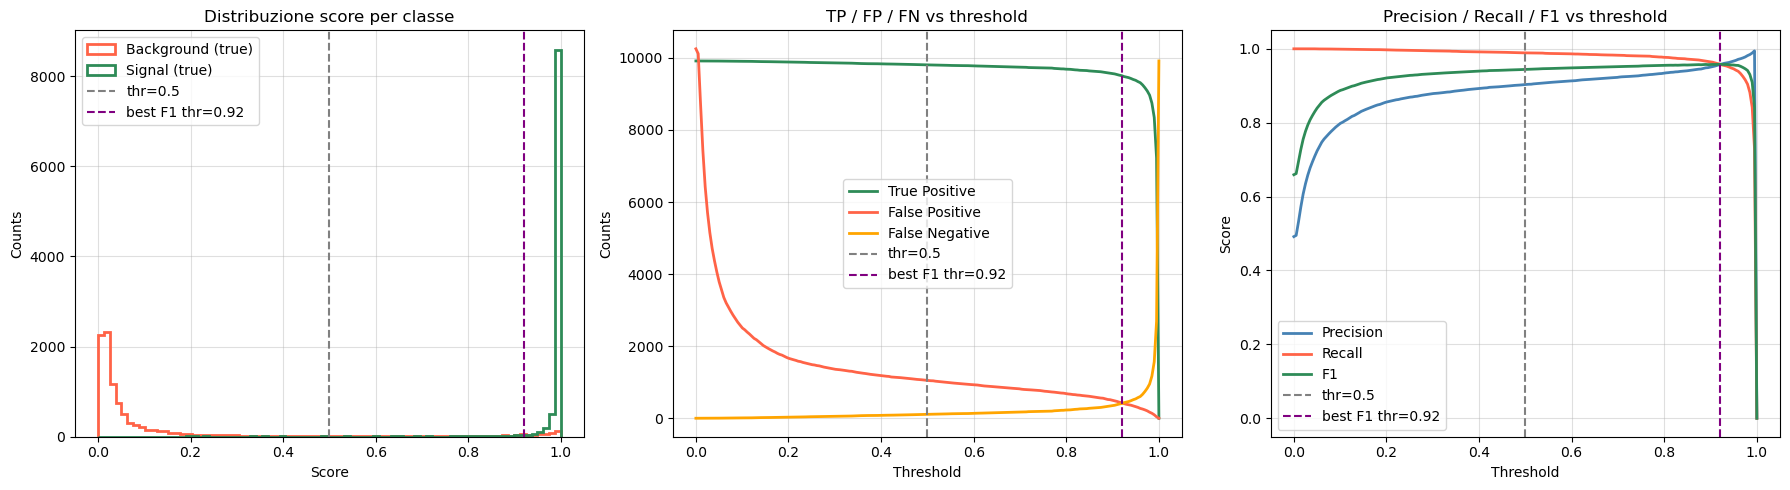

In [214]:
thresholds = np.linspace(0, 1, 200)

tp_counts, fp_counts, fn_counts, tn_counts = [], [], [], []
precision_list, recall_list, f1_list = [], [], []

for thr in thresholds:
    yp = (prob > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0,1]).ravel()
    tp_counts.append(tp)
    fp_counts.append(fp)
    fn_counts.append(fn)
    tn_counts.append(tn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)

best_thr = thresholds[np.argmax(f1_list)]
print(f"Best threshold (F1): {best_thr:.3f}  →  F1={max(f1_list):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Distribuzione score per classe ─────────────────────────────────────────
ax = axes[0]
score_sig = prob[y_test == 1]
score_bkg = prob[y_test == 0]
sbins = np.linspace(0, 1, 80)
ax.hist(score_bkg, bins=sbins, histtype="step", linewidth=2, color="tomato",   label="Background (true)")
ax.hist(score_sig, bins=sbins, histtype="step", linewidth=2, color="seagreen", label="Signal (true)")
ax.axvline(0.5,      color="gray",   linestyle="--", linewidth=1.5, label="thr=0.5")
ax.axvline(best_thr, color="purple", linestyle="--", linewidth=1.5, label=f"best F1 thr={best_thr:.2f}")
ax.set_xlabel("Score")
ax.set_ylabel("Counts")
ax.set_title("Distribuzione score per classe")
ax.legend()
ax.grid(True, alpha=0.4)

# ── 2. TP / FP / FN vs threshold ──────────────────────────────────────────────
ax = axes[1]
ax.plot(thresholds, tp_counts, color="seagreen", linewidth=2, label="True Positive")
ax.plot(thresholds, fp_counts, color="tomato",   linewidth=2, label="False Positive")
ax.plot(thresholds, fn_counts, color="orange",   linewidth=2, label="False Negative")
ax.axvline(0.5,      color="gray",   linestyle="--", linewidth=1.5, label="thr=0.5")
ax.axvline(best_thr, color="purple", linestyle="--", linewidth=1.5, label=f"best F1 thr={best_thr:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Counts")
ax.set_title("TP / FP / FN vs threshold")
ax.legend()
ax.grid(True, alpha=0.4)

# ── 3. Precision / Recall / F1 vs threshold ───────────────────────────────────
ax = axes[2]
ax.plot(thresholds, precision_list, color="steelblue", linewidth=2, label="Precision")
ax.plot(thresholds, recall_list,    color="tomato",    linewidth=2, label="Recall")
ax.plot(thresholds, f1_list,        color="seagreen",  linewidth=2, label="F1")
ax.axvline(0.5,      color="gray",   linestyle="--", linewidth=1.5, label="thr=0.5")
ax.axvline(best_thr, color="purple", linestyle="--", linewidth=1.5, label=f"best F1 thr={best_thr:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs threshold")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Threshold ottimale (max precision con recall≥0.99): 0.467
  Precision : 0.900
  Recall    : 0.990
  F1        : 0.943


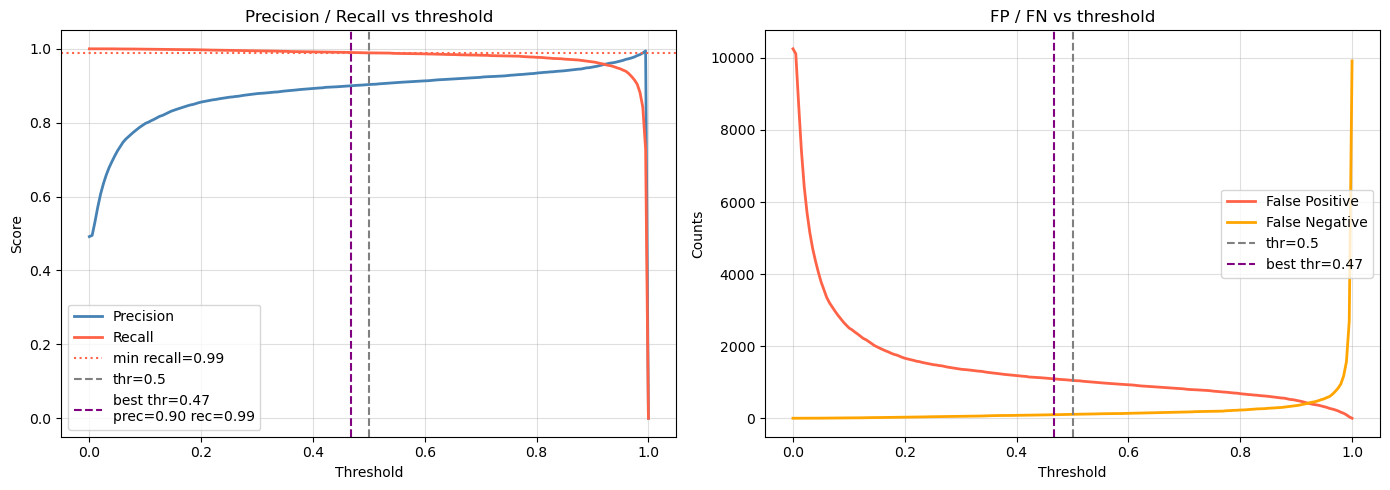

In [215]:
min_recall = 0.99  # segnale minimo che vuoi recuperare — aggiusta a piacere

valid_mask = np.array(recall_list) >= min_recall
valid_thrs = thresholds[valid_mask]
valid_prec = np.array(precision_list)[valid_mask]

best_thr_prec = valid_thrs[np.argmax(valid_prec)]
best_prec     = valid_prec.max()
best_rec_at   = np.array(recall_list)[valid_mask][np.argmax(valid_prec)]
best_f1_at    = np.array(f1_list)[valid_mask][np.argmax(valid_prec)]

print(f"Threshold ottimale (max precision con recall≥{min_recall}): {best_thr_prec:.3f}")
print(f"  Precision : {best_prec:.3f}")
print(f"  Recall    : {best_rec_at:.3f}")
print(f"  F1        : {best_f1_at:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. Precision / Recall vs threshold ───────────────────────────────────────
ax = axes[0]
ax.plot(thresholds, precision_list, color="steelblue", linewidth=2, label="Precision")
ax.plot(thresholds, recall_list,    color="tomato",    linewidth=2, label="Recall")
ax.axhline(min_recall,    color="tomato",  linestyle=":",  linewidth=1.5, label=f"min recall={min_recall}")
ax.axvline(0.5,           color="gray",    linestyle="--", linewidth=1.5, label="thr=0.5")
ax.axvline(best_thr_prec, color="purple",  linestyle="--", linewidth=1.5,
           label=f"best thr={best_thr_prec:.2f}\nprec={best_prec:.2f} rec={best_rec_at:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall vs threshold")
ax.legend()
ax.grid(True, alpha=0.4)

# ── 2. FP / FN vs threshold ───────────────────────────────────────────────────
ax = axes[1]
ax.plot(thresholds, fp_counts, color="tomato",  linewidth=2, label="False Positive")
ax.plot(thresholds, fn_counts, color="orange",  linewidth=2, label="False Negative")
ax.axvline(0.5,           color="gray",   linestyle="--", linewidth=1.5, label="thr=0.5")
ax.axvline(best_thr_prec, color="purple", linestyle="--", linewidth=1.5,
           label=f"best thr={best_thr_prec:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Counts")
ax.set_title("FP / FN vs threshold")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# aggiorna threshold per i plot successivi
threshold = best_thr_prec

### Visualization of the data selected against the true values

Veri prompt (label1==1)         : 9974
Selezionati dal modello         : 10032
True Positive (veri+selezionati): 9646
Efficiency  (TP / veri)         : 0.967
Purity      (TP / selezionati)  : 0.962


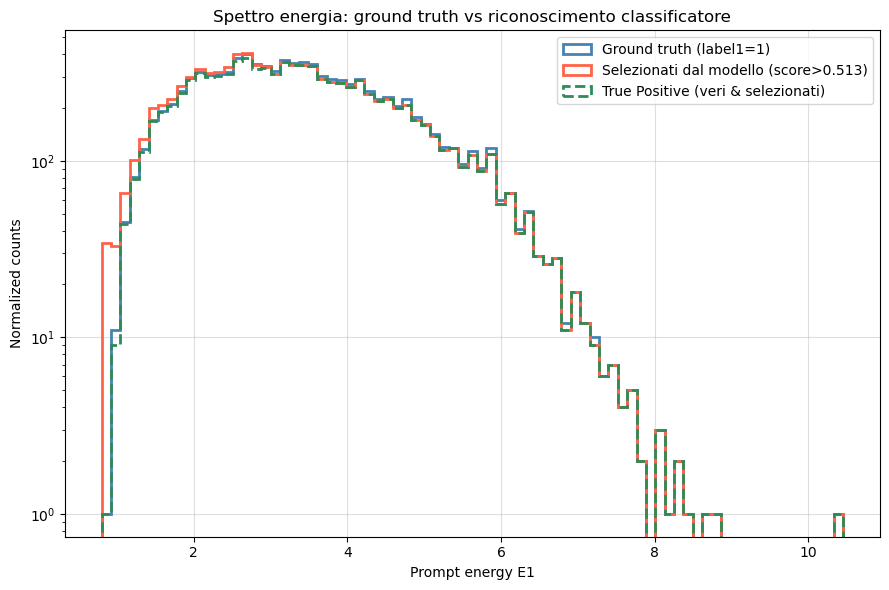

CONFUSION MATRIX
[[9862  390]
 [ 273 9642]]


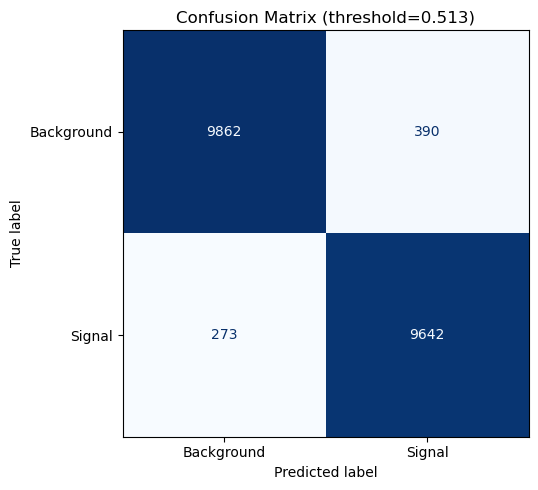

True Negative  (BG corretto)  : 9862
False Positive (BG→Signal)    : 390
False Negative (Signal→BG)    : 273
True Positive  (Signal corr.) : 9642
Precision : 0.961
Recall    : 0.972
F1        : 0.967


In [328]:
#threshold = 0.513
threshold =0.7
# prob è già calcolato su test set
true_prompt_mask      = test["label1"] == 1
predicted_prompt_mask = prob > threshold

# Energia nei tre casi
E_true      = test.loc[true_prompt_mask,                          "E1"]
E_predicted = test.loc[predicted_prompt_mask,                     "E1"]
E_tp        = test.loc[true_prompt_mask & predicted_prompt_mask,  "E1"]

print(f"Veri prompt (label1==1)         : {len(E_true)}")
print(f"Selezionati dal modello         : {len(E_predicted)}")
print(f"True Positive (veri+selezionati): {len(E_tp)}")
print(f"Efficiency  (TP / veri)         : {len(E_tp)/len(E_true):.3f}")
print(f"Purity      (TP / selezionati)  : {len(E_tp)/len(E_predicted):.3f}")

bins = np.linspace(test["E1"].min(), test["E1"].max(), 80)

plt.figure(figsize=(9, 6))
plt.hist(E_true,      bins=bins, density=False, histtype="step",linewidth=2, color="steelblue", label="Ground truth (label1=1)")
plt.hist(E_predicted, bins=bins, density=False, histtype="step",linewidth=2, color="tomato",    label=f"Selezionati dal modello (score>{threshold})")
plt.hist(E_tp,        bins=bins, density=False, histtype="step", linewidth=2, color="seagreen",  linestyle="--", label="True Positive (veri & selezionati)")
plt.yscale("log")
plt.xlabel("Prompt energy E1")
plt.ylabel("Normalized counts")
plt.title("Spettro energia: ground truth vs riconoscimento classificatore")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

y_pred = (prob > threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

print("CONFUSION MATRIX")
print(cm)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (prob > threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Background", "Signal"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix (threshold={threshold})")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (BG corretto)  : {tn}")
print(f"False Positive (BG→Signal)    : {fp}")
print(f"False Negative (Signal→BG)    : {fn}")
print(f"True Positive  (Signal corr.) : {tp}")
print(f"Precision : {tp/(tp+fp):.3f}")
print(f"Recall    : {tp/(tp+fn):.3f}")
print(f"F1        : {2*tp/(2*tp+fp+fn):.3f}")

In [327]:
booster  = model.get_booster()
trees_df = booster.trees_to_dataframe()

leaves = (trees_df["Feature"] == "Leaf").sum()
nodes  = (trees_df["Feature"] != "Leaf").sum()
total  = leaves + nodes * 2

print(f"Foglie      : {leaves}")
print(f"Nodi interni: {nodes}")
print(f"Parametri   : {total}")

Foglie      : 1169
Nodi interni: 1049
Parametri   : 3267


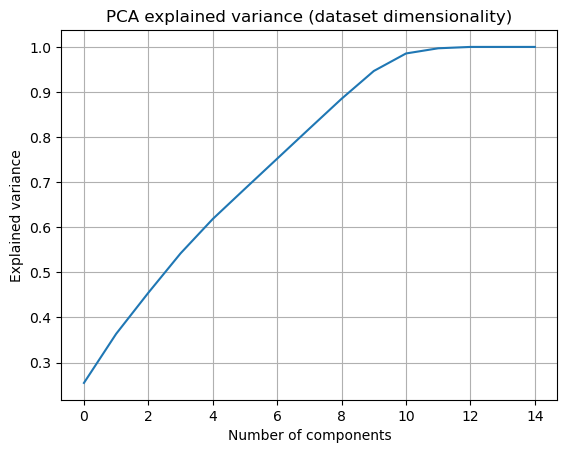


Effective dimensionality (~95% variance): 11


In [325]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained)
plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.title("PCA explained variance (dataset dimensionality)")
plt.grid()
plt.show()

print("\nEffective dimensionality (~95% variance):",np.argmax(explained > 0.95) + 1)